<center>
    <img src="https://catalog.wlimg.com/4/547602/small-images/hotel-booking-86689.jpg" width="700" height="400">
</center>

<center>
    <font size="6">INN Hotel Booking Cancellation Predictor</font>
</center>

#### Context
A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.
**The cancellation of bookings impacts a hotel on various fronts:**
1. Loss of resources (revenue) when the hotel cannot resell the room.
2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
3. Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
4. Human resources to make arrangements for the guests.

#### Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.



## Importing necessary libraries..

In [ ]:
# libraies to help with reading and manipulating data
import numpy as np
import pandas as pd

# libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset..

In [ ]:
# Mounting Google Drive to access the dataset
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/INNHotelsGroup.csv")

## Data Overview..

View the first and last 5 rows of the dataset:-

In [ ]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


#### Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.
##### **Data Dictionary**
- **Booking_ID:** the unique identifier of each booking
- **no_of_adults:** Number of adults
- **no_of_children:** Number of Children
- **no_of_weekend_nights:** Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- **no_of_week_nights:** Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel
- **type_of_meal_plan:** Type of meal plan booked by the customer:
Not Selected – No meal plan selected
Meal Plan 1 – Breakfast
Meal Plan 2 – Half board (breakfast and one other meal)
Meal Plan 3 – Full board (breakfast, lunch, and dinner)
- **required_car_parking_space:** Does the customer require a car parking space? (0 - No, 1- Yes)
- **room_type_reserved:** Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group
- **lead_time:** Number of days between the date of booking and the arrival date
- **arrival_year:** Year of arrival date
- **arrival_month:** Month of arrival date
- **arrival_date:** Date of the month
- **market_segment_type:** Market segment designation.
- **repeated_guest:** Is the customer a repeated guest? (0 - No, 1- Yes)
- **no_of_previous_cancellations:** Number of previous bookings that were canceled by the customer before the current booking
- **no_of_previous_bookings_not_canceled:** Number of previous bookings not canceled by the customer before the current booking
- **avg_price_per_room:** Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- **no_of_special_requests:** Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- **booking_status:** Flag indicating if the booking was canceled or not.


## Understand the shape of the dataset..

In [ ]:
data.shape

(36275, 19)

- The dataset has 36,275 rows and 19 columns.

## Check  the data types of the columns for the dataset..

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

#### **Observation :-**
1. **Dataset Size & Shape:** The dataset is quite large, containing a total of 36,275 entries (rows) and 19 features (columns).

2. **Missing Values Check:** By looking at the "Non-Null Count", every column has exactly 36,275 non-null entries. This is excellent news because it means there are zero missing (null) values in the entire dataset. We do not need to perform any data imputation (filling missing data) for this dataset.

3. **Data Types Distribution:**

- **Numerical Features (14):** There are 13 integer columns (int64) and 1 float column (float64). These represent quantifiable data such as the number of guests, lead time, and average price per room.

- **Categorical Features (5):** There are 5 columns with the object data type, which means they contain text or categorical strings (e.g., Booking_ID, type_of_meal_plan, booking_status).

## Checking for duplicate values..

In [ ]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

## Checking for missing values..

In [ ]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


- There are no missing values in the dataset.

## Statistical Summary..

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


#### Observation :-  
1. **Booking Demographics:**
- The majority of the bookings consist of 2 adults and 0 children (as observed from the 50th and 75th percentiles).

- Interestingly, the minimum value for no_of_adults is 0.0. A booking with zero adults might indicate a potential data entry error or a booking made exclusively for children, which requires further investigation.

2. **Extreme Variance in Lead Time:**
- The lead_time feature shows significant variance. While the average lead time is ~85 days, the standard deviation is massive (86 days).

- The gap between the 75th percentile (126 days) and the maximum value (443+ days) indicates a strong right-skewed distribution with several high-value outliers.

3. **Anomalies in Room Pricing:**
- The avg_price_per_room has a minimum value of 0.0. This is a critical anomaly that could represent complimentary rooms, loyalty reward bookings, or missing/erroneous data.

- Additionally, there is a massive jump from the 75th percentile (120) to the maximum value (540+), indicating extreme outliers on the higher pricing side.

4. **Rare Events (Imbalanced Features):**

- Features such as required_car_parking_space, repeated_guest, and no_of_previous_cancellations consist mostly of 0s (even at their 75th percentiles). This tells us that returning guests, cancellations, and parking requests are relatively rare events in this dataset.

In [ ]:
# Filter bookings where no adults are present
zero_adults = data[data['no_of_adults'] == 0]
print(f"Total bookings with 0 Adults: {len(zero_adults)}")

# Display the first 3 rows to investigate why adults are 0
print("\nPeek into '0 Adults' records:")
display(zero_adults[['no_of_adults', 'no_of_children', 'avg_price_per_room']].head(3))

print("-" * 50)

# Filter bookings where the room price is 0.0
zero_price = data[data['avg_price_per_room'] == 0.0]
print(f"Total bookings with Price 0.0: {len(zero_price)}")

# Display the first 3 rows to investigate why the price is 0
print("\nPeek into '0.0 Price' records:")
display(zero_price[['no_of_adults', 'market_segment_type', 'avg_price_per_room']].head(3))

Total bookings with 0 Adults: 139

Peek into '0 Adults' records:


,no_of_adults,no_of_children,avg_price_per_room
32,0,2,82.44
287,0,2,108.38
653,0,2,115.68


--------------------------------------------------
Total bookings with Price 0.0: 545

Peek into '0.0 Price' records:


,no_of_adults,market_segment_type,avg_price_per_room
63,1,Complementary,0.0
145,1,Complementary,0.0
209,1,Complementary,0.0


#### Observation :-  

1. **The '0 Adults' Bookings (139 Records):**

- Upon filtering the 139 records with 0 adults, we observed that these bookings have children associated with them (e.g., 2 children) and possess a valid room price.

- *Conclusion:* This is not a data entry error. It strongly indicates a real-world hotel scenario where parents book a separate, adjoining room exclusively for their children. Therefore, these records are logically valid and should be retained in the dataset.

2. **The '0.0 Price' Bookings (545 Records):**

- Filtering the 545 zero-price room bookings revealed that their market_segment_type is strictly categorized as "Complementary".

- *Conclusion:* These are not missing or erroneous price values. They represent free rooms officially provided by the hotel (likely for loyalty program rewards, staff, or promotional offers). These are valid business transactions and must remain intact for accurate model training.

## Drop unnecessary columns..

In [ ]:
clean_data = data.drop(["Booking_ID","arrival_year"], axis = 1)

print("Unnecessary columns dropped successfully !")
print(f"New Dataset Shape: {clean_data.shape}")

print("\n Remaining Columns:")
print(clean_data.columns.tolist())

Unnecessary columns dropped successfully !
New Dataset Shape: (36275, 17)

 Remaining Columns:
['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


#### Observation :-  
- **Booking_ID:** Removed because it is a unique identifier with no predictive value. Keeping it could lead to model overfitting.

- **arrival_year:** Removed to prevent the model from memorizing specific historical years, ensuring the model generalizes well for future bookings.

### The dataset is now leaner, with no "noise", making it fully optimized for Machine Learning.

# <a name='link2'>Exploratory Data Analysis (EDA) Questions..</a>

#### **1. What are the busiest months in the hotel?**

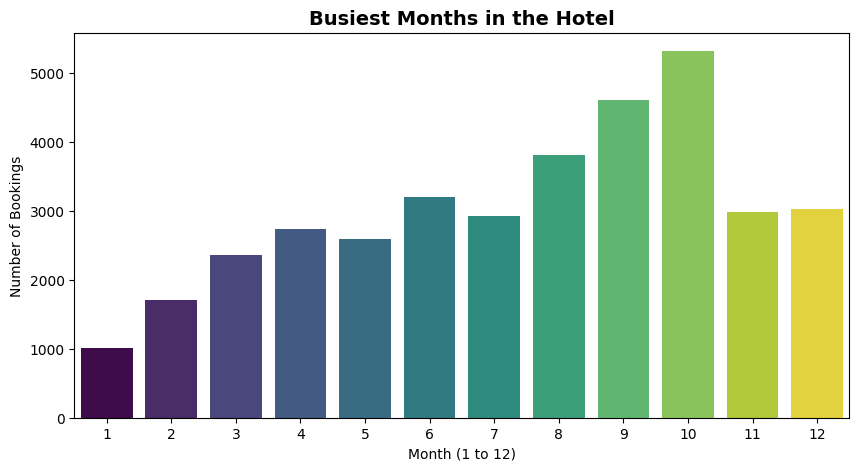

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = clean_data, x = "arrival_month", hue = "arrival_month", palette = "viridis", legend = False)
plt.title("Busiest Months in the Hotel", fontsize = 14, fontweight = "bold")
plt.xlabel("Month (1 to 12)")
plt.ylabel("Number of Bookings")
plt.show()

- The absolute busiest month in the hotel is October (Month 10), recording the highest number of bookings (over 5,000). The broader peak season occurs during the late summer and early autumn period, specifically spanning across August (Month 8), September (Month 9), and October (Month 10).

#### **2. Which market segment do most of the guests come from?**

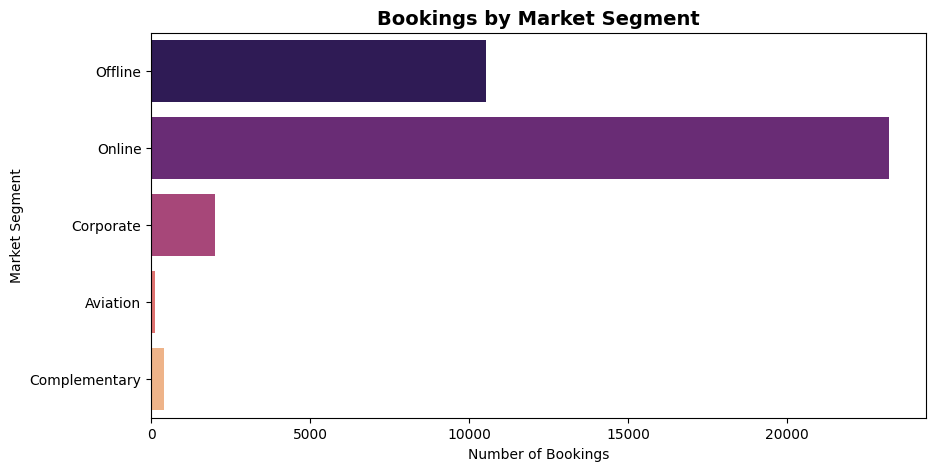

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = clean_data, y = "market_segment_type", hue = "market_segment_type", palette = "magma", legend = False)
plt.title("Bookings by Market Segment", fontsize = 14, fontweight = "bold")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")
plt.show()

- Most of the guests come from the 'Online' market segment (over 23,000 bookings). It is the absolute biggest source of business for the hotel, bringing in more than double the guests compared to the second-highest 'Offline' segment.

#### **3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

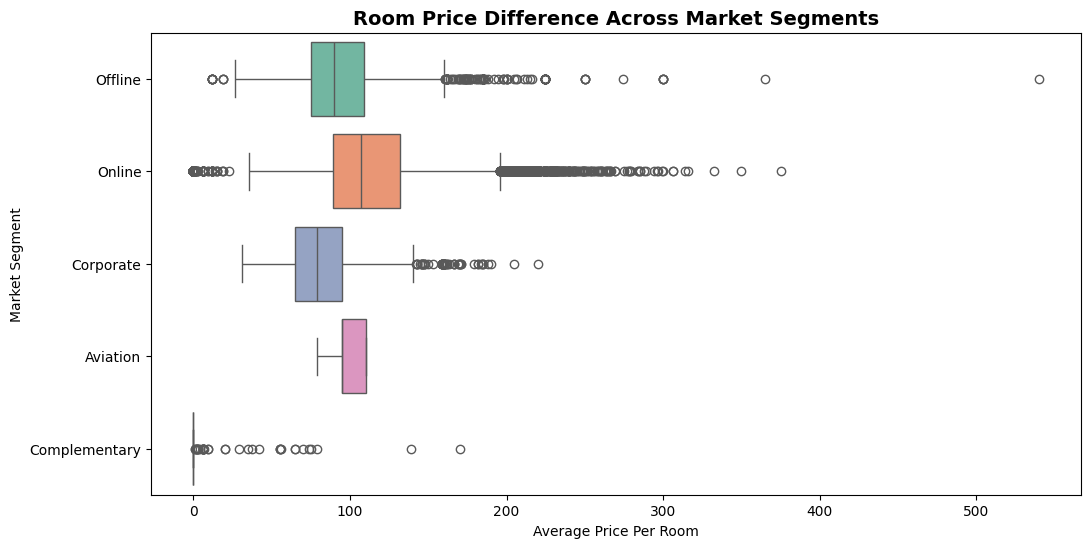

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=clean_data, x = "avg_price_per_room", y = "market_segment_type", hue = "market_segment_type", palette = "Set2", legend = False)
plt.title("Room Price Difference Across Market Segments", fontsize = 14, fontweight = "bold")
plt.xlabel("Average Price Per Room")
plt.ylabel("Market Segment")
plt.show()

- **Highest & Most Dynamic Prices:** The 'Online' segment generally pays the highest room rates (highest median) and shows the widest price variation. This reflects dynamic pricing where rates change frequently based on online demand.

- **Lower/Negotiated Prices:** The 'Corporate' segment has noticeably lower median prices and a much tighter range, indicating stable, pre-negotiated fixed rates for business clients.

- **Free Rooms:** As expected, the 'Complementary' segment sits at a baseline of zero, representing free stays.

#### **4. What percentage of bookings are canceled?**

Overall Cancellation Percentage:
 booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


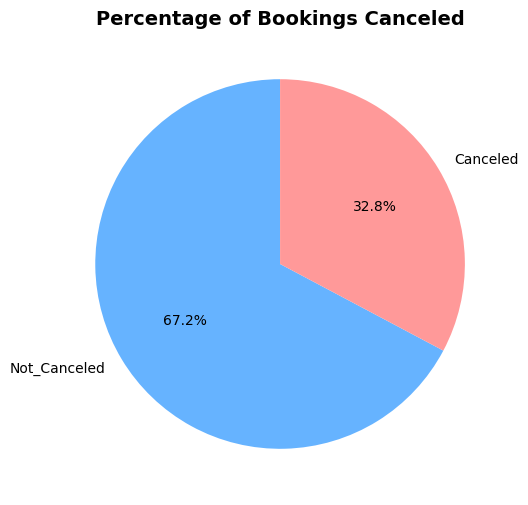

In [ ]:
cancel_pct = clean_data["booking_status"].value_counts(normalize=True) * 100
print("Overall Cancellation Percentage:\n", cancel_pct)

plt.figure(figsize=(6,6))
plt.pie(cancel_pct, labels=cancel_pct.index, autopct="%1.1f%%", startangle = 90, colors = ["#66b3ff", "#ff9999"] )
plt.title("Percentage of Bookings Canceled", fontsize = 14, fontweight = "bold")
plt.show()

- **Cancellation Percentage:** Exactly 32.8% of the total hotel bookings end up being canceled, while the remaining 67.2% are successfully completed.

- **Business Impact:** This means that roughly 1 out of every 3 bookings results in a cancellation. This is a significantly high cancellation rate, highlighting a major area of potential revenue loss that our Machine Learning model needs to help predict and minimize.

#### **5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

Cancellation Percentage for Repeating Guests : 
 booking_status
Not_Canceled    98.27957
Canceled         1.72043
Name: proportion, dtype: float64


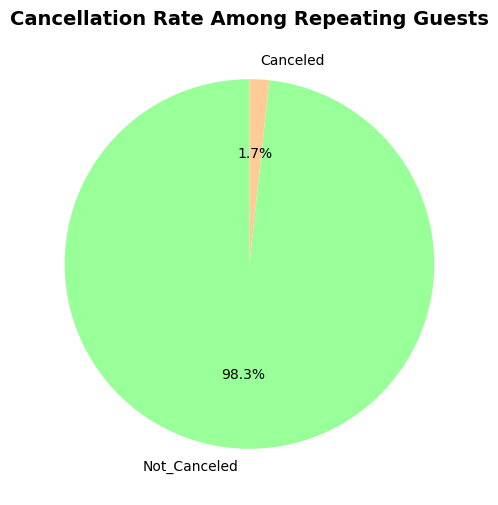

In [ ]:
rep_guests = clean_data[clean_data["repeated_guest"] == 1]

rep_cancel_pct = rep_guests["booking_status"].value_counts(normalize=True) * 100
print("Cancellation Percentage for Repeating Guests : \n", rep_cancel_pct)

plt.figure(figsize = (6,6))
plt.pie(rep_cancel_pct, labels = rep_cancel_pct.index, autopct="%1.1f%%", startangle=90, colors=["#99ff99","#ffcc99"])
plt.title("Cancellation Rate Among Repeating Guests", fontsize = 14, fontweight = "bold")
plt.show()

- **Cancellation Percentage:** Only a mere 1.7% of repeating guests cancel their hotel bookings, with an overwhelming 98.3% successfully completing their stay.

- **Business Impact:** Compared to the overall average cancellation rate, this is incredibly low. It clearly proves that loyal, returning customers are highly reliable and essential for brand equity. The hotel management should heavily invest in loyalty programs to convert more first-time visitors into repeating guests.

#### **6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

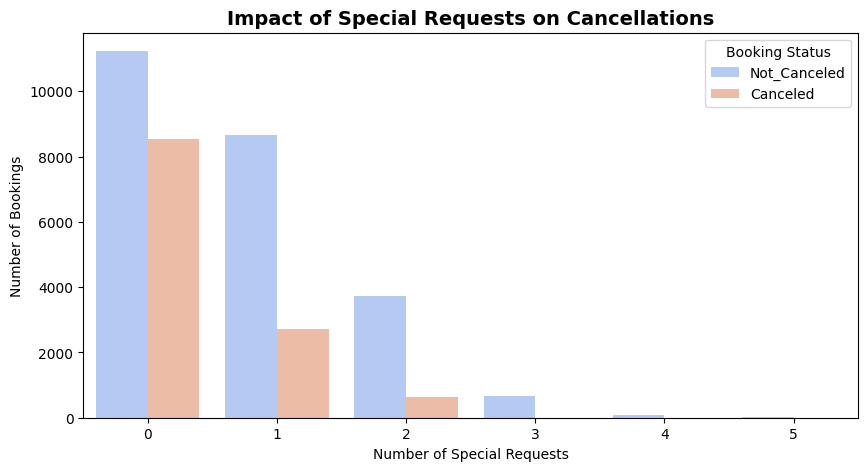

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = clean_data, x = "no_of_special_requests", hue = "booking_status", palette = "coolwarm")
plt.title("Impact of Special Requests on Cancellations", fontsize = 14, fontweight = "bold")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")
plt.legend(title = "Booking Status")
plt.show()

- **Clear Inverse Trend:** Yes, special requirements strongly affect cancellations. The graph shows a clear inverse relationship: as the number of special requests increases, the likelihood of cancellation dramatically decreases.

- **High Risk (0 Requests):** Guests who make zero special requests have the highest cancellation rate. The orange bar (Canceled) is alarmingly high compared to the blue bar (Not_Canceled) in this category.

- **High Commitment (1+ Requests):** As soon as a guest makes 1, 2, or more special requests, the proportion of cancellations drops significantly. For 3 or more requests, cancellations are almost non-existent.

- **Business Impact:** Making a special request shows higher guest engagement and commitment to the trip. The hotel can safely consider bookings with 1 or more special requests as highly secure.

### Univariate analysis..

In [ ]:
def histogram_boxplot(data, feature, figsize=(15,10), kde = False, bins=None):
  """
  Boxplot and histplot combined

  data: dataframe
  feature: dataframe column
  figsize: size of figure (default (15,10))
  kde: whether to show the density curve (default False)
  bins: number of bins for histgrom (default None)
  """
  f2, (ax_box2, ax_hist2) = plt.subplots(
      nrows = 2, # Number of rows of the subplot grid = 2
      sharex = True, # x-axis will be shared among all subplots
      gridspec_kw = {"height_ratios": (0.25, 0.75)},
      figsize = figsize,
  ) # Creating the 2 subplots
  sns.boxplot(
      data = data, x=feature, ax=ax_box2, showmeans=True, color = "teal"
  ) # Boxplot will be created and a tringle will indicate the mean value of the column
  sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
  ) if bins else sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2
  ) # For histgrom
  ax_hist2.axvline(
      data[feature].mean(), color="green", linestyle="--"
  ) # Add mean to the histogram
  ax_hist2.axvline(
      data[feature].median(),color="black", linestyle="-"
  ) # Add median to the histgrom

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observation on no_of_adults :-

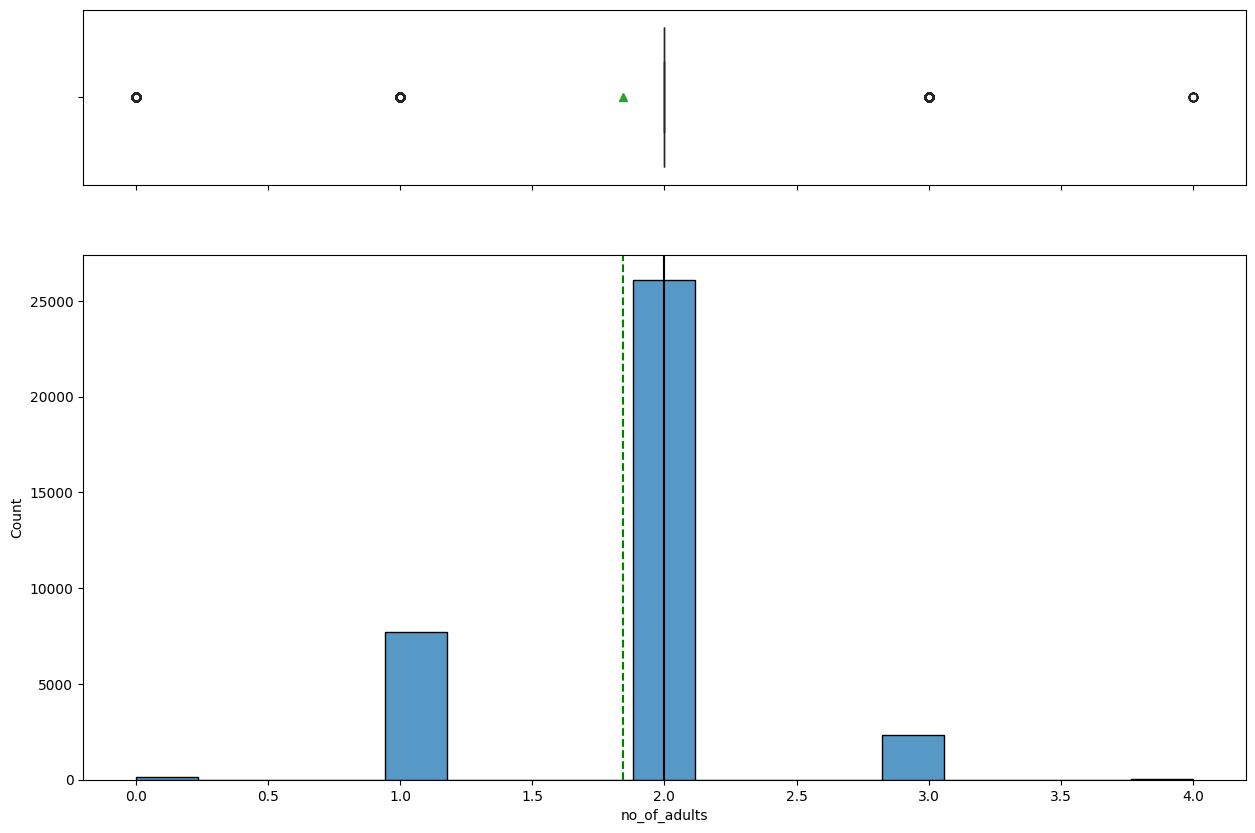

In [ ]:
histogram_boxplot(clean_data, "no_of_adults")

- **Primary Customer Base:** The vast majority of bookings are for exactly 2 adults (over 25,000 bookings), making couples or pairs the core demographic for the hotel.

- **Secondary Base:** Solo travelers (1 adult) form the second-largest group.

- **Rare Bookings:** Group stays (3 or 4 adults) and special cases (0 adults) are very rare. Because the data is so heavily concentrated at '2', the boxplot collapses and marks all other values as statistical outliers.

#### Observation on no_of_children :-

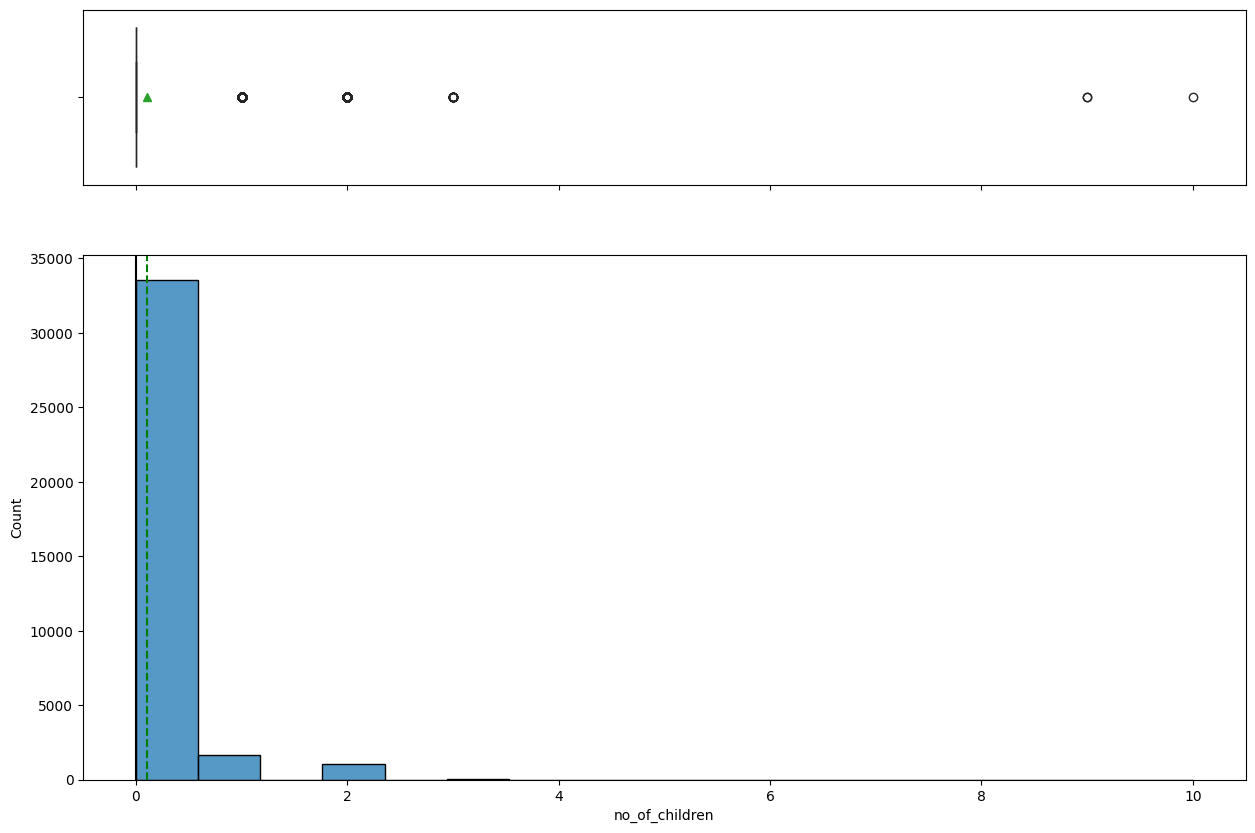

In [ ]:
histogram_boxplot(clean_data,"no_of_children")

- **Zero Children Dominance:** The overwhelming majority of hotel bookings (over 33,000) have 0 children. This strongly reinforces our earlier finding that the hotel primarily caters to adult couples and solo travelers rather than families.

- **Families are a Minority:** Bookings that include 1 or 2 children make up a very small fraction of the total business.

- **Extreme Outliers:** The boxplot clearly flags higher numbers as statistical outliers. Specifically, there are extreme rare cases with 9 or 10 children in a single booking, which could represent large group/school trips or potential data entry errors.

#### Observation on no_of_weekend_nights :-

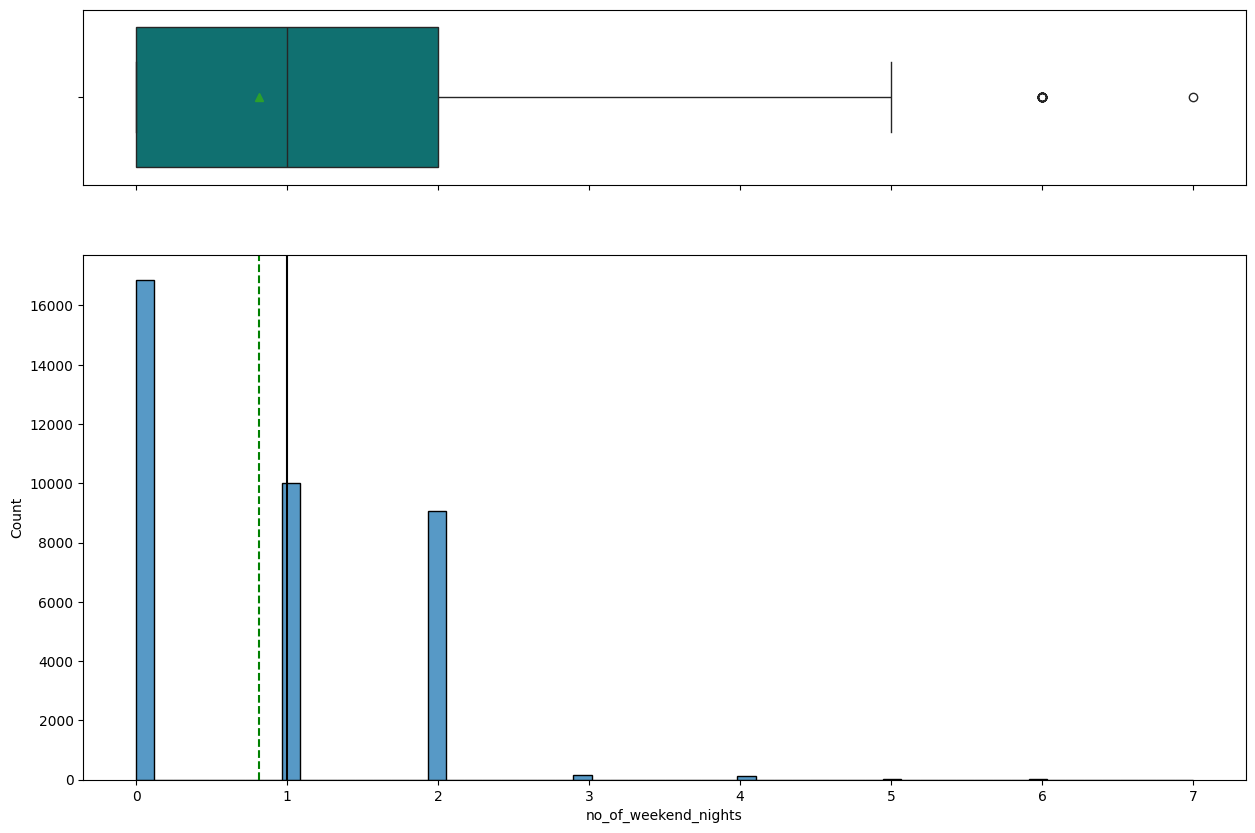

In [ ]:
histogram_boxplot(clean_data, "no_of_weekend_nights")

- **Weekday Dominance:** The most frequent value is 0 weekend nights (around 17,000 bookings). This indicates that a large portion of the hotel's guests stay strictly during the weekdays (Monday to Friday), which strongly points towards business or corporate travelers.

- **Standard Weekend Getaways:** Bookings with 1 or 2 weekend nights are also highly common. These represent standard weekend tourists or short leisure trips.

- **Long Stays (Outliers):** Bookings containing 3 or more weekend nights are extremely rare. The boxplot clearly flags stays with 6 or 7 weekend nights as extreme outliers, because having 6-7 weekend nights implies the guest stayed at the hotel for almost 3 to 4 weeks!

#### Observation on no_of_week_nights :-

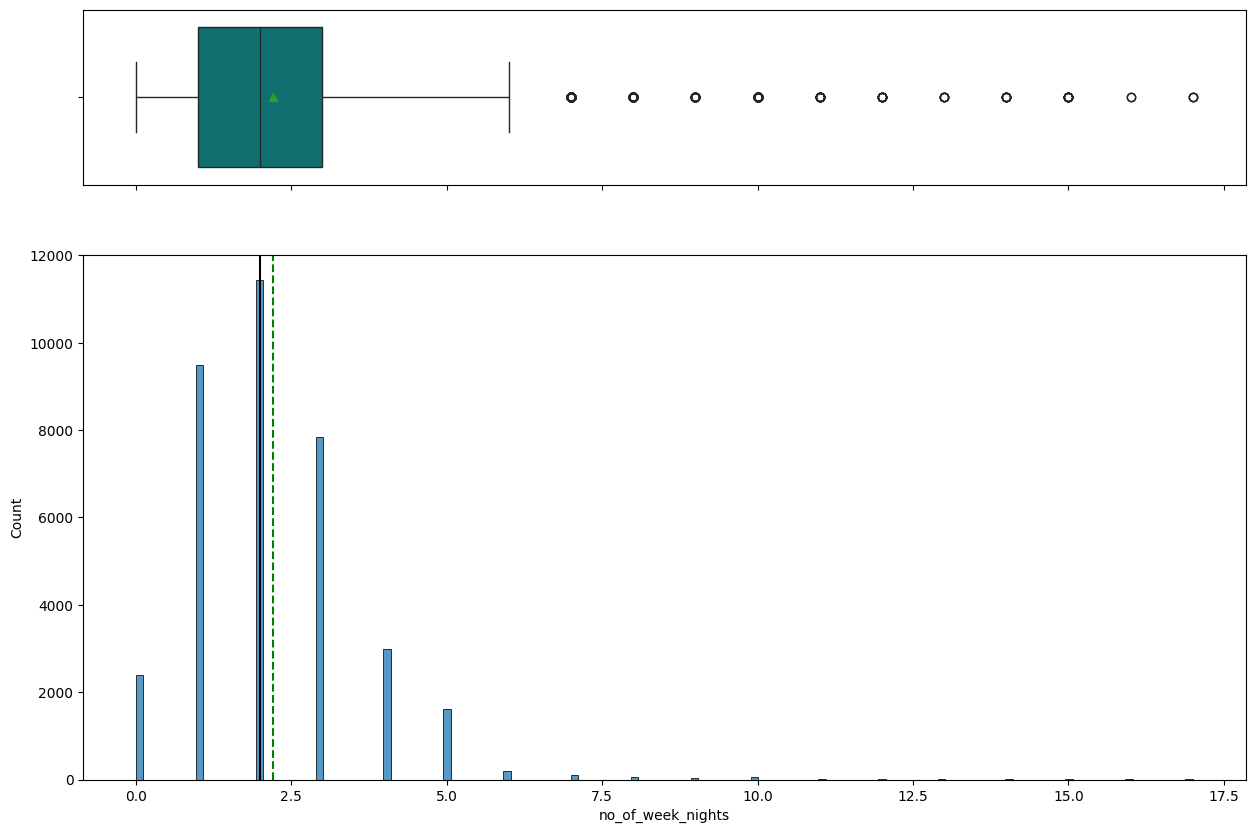

In [ ]:
histogram_boxplot(clean_data, "no_of_week_nights")

- **Standard Stay Duration:** The vast majority of guests stay for 1 to 3 week nights, with exactly 2 week nights being the most frequent booking (peaking at over 11,000 counts). This is very typical for short business trips or mid-week travel.

- **Weekend-Only Guests:** There is a small but noticeable group with 0 week nights. These are the guests who strictly check-in and check-out during the weekend, completely skipping the weekdays.

- **Long-Term Outliers:** The distribution is heavily right-skewed. Bookings for more than 5 week nights drop off drastically. The boxplot clearly marks any stay extending beyond 6 or 7 week nights (going all the way up to 17 nights) as statistical outliers, representing very rare long-term guests.

#### Observation on type_of_meal_plan :-

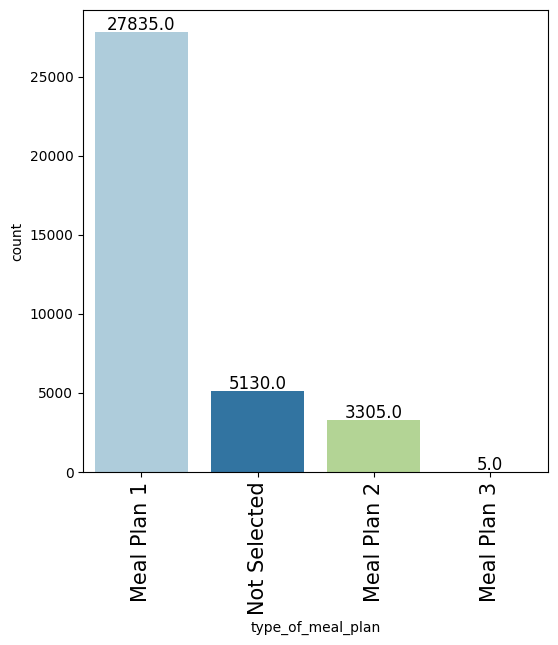

In [ ]:
labeled_barplot(clean_data, "type_of_meal_plan")

- **Standard Plan Dominance:** The vast majority of guests (27,835 bookings) choose Meal Plan 1. This is clearly the standard, most popular, or default food package offered by the hotel.

- **No Meals Chosen:** The second most common category is Not Selected (5,130 bookings). A significant portion of guests prefer room-only bookings, likely choosing to eat outside the hotel.

- **Rare Choices:** Meal Plan 2 has a much lower adoption rate (3,305 bookings), and Meal Plan 3 is practically non-existent with only 5 bookings out of the entire dataset.

#### Observation on required_car_parking_space :-

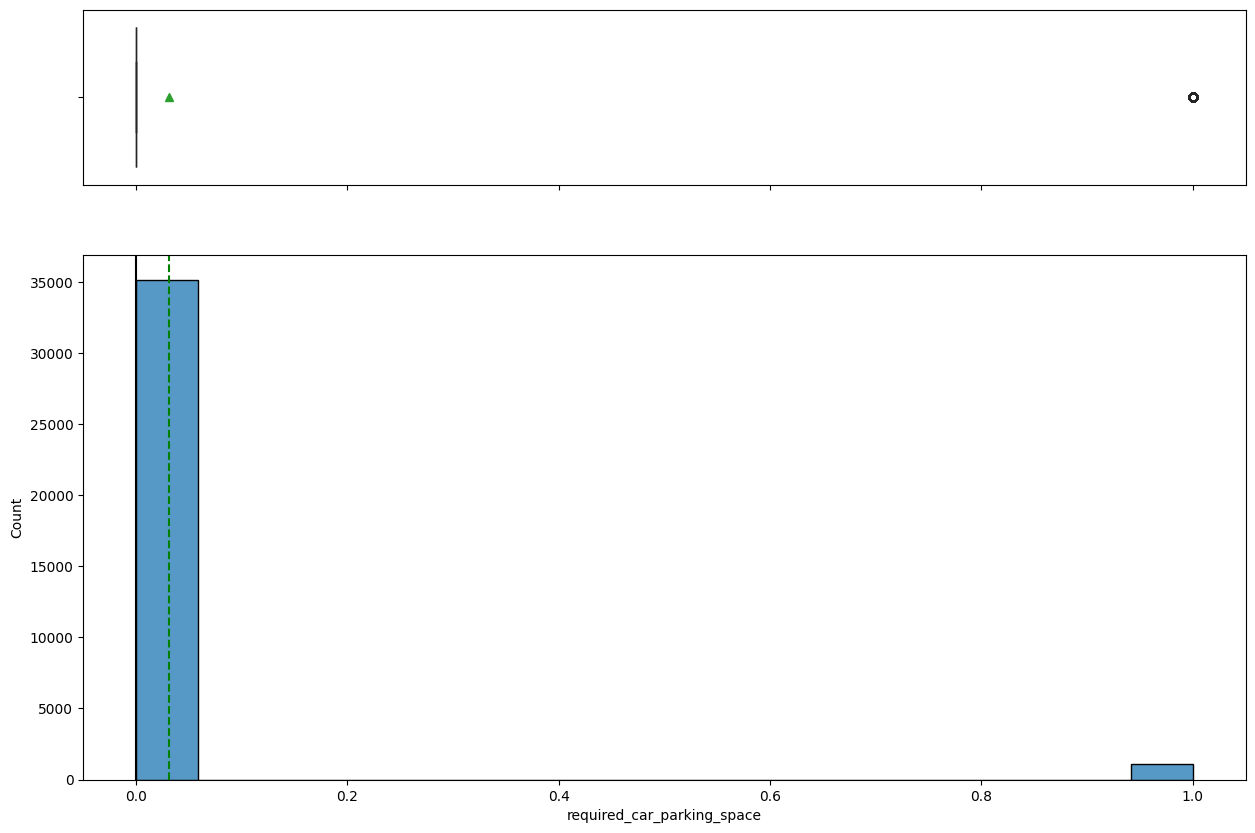

In [ ]:
histogram_boxplot(clean_data, "required_car_parking_space")

- **Parking is Rarely Needed:** The data shows a massive imbalance. The overwhelming majority of guests (over 35,000 bookings) do not require a car parking space (value 0). This suggests that most guests travel via public transport, taxis, or flights rather than driving their own personal vehicles to the hotel.

- **A Rare Feature:** Only a tiny fraction of the total bookings (around 1,000) requested a parking space (value 1). Because almost the entire dataset sits at 0, the boxplot collapses and marks any request for parking (1) as a statistical outlier.

#### Observation on room_type_reserved :-

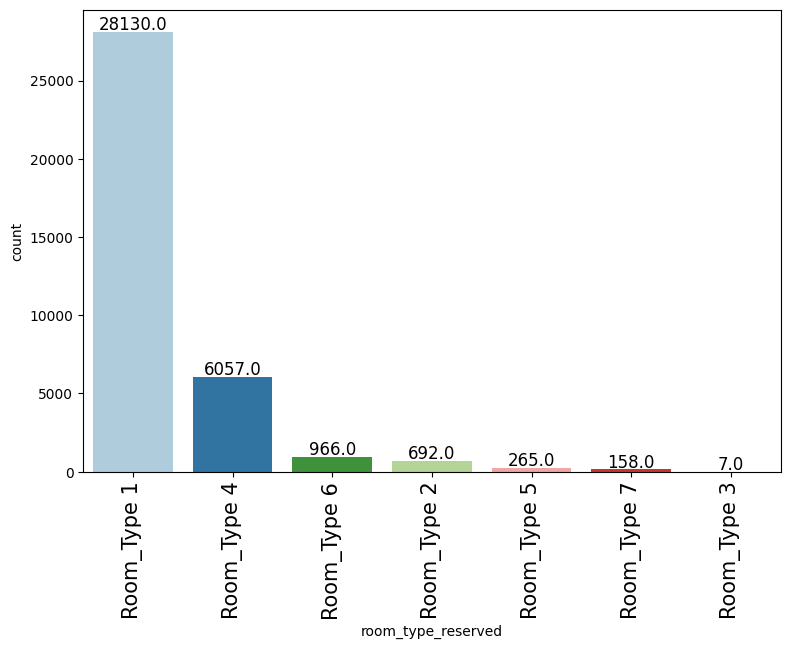

In [ ]:
labeled_barplot(clean_data, "room_type_reserved")

- **Standard Room Dominance:** Room_Type 1 is overwhelmingly the most popular choice, with over 28,000 bookings. This strongly indicates that it is the standard, basic, or most affordable room category offered by the hotel.

- **Secondary Preference:** Room_Type 4 is the second most requested category (over 6,000 bookings), likely representing the next tier up, such as a premium, deluxe, or larger family room.

- **Rarely Booked Rooms:** All other room types (6, 2, 5, 7, and 3) have very low booking volumes. Room_Type 3 is almost non-existent in the dataset with only 7 total bookings, which might represent a highly exclusive suite or a rare special-category room.

#### Observation on lead_time :-

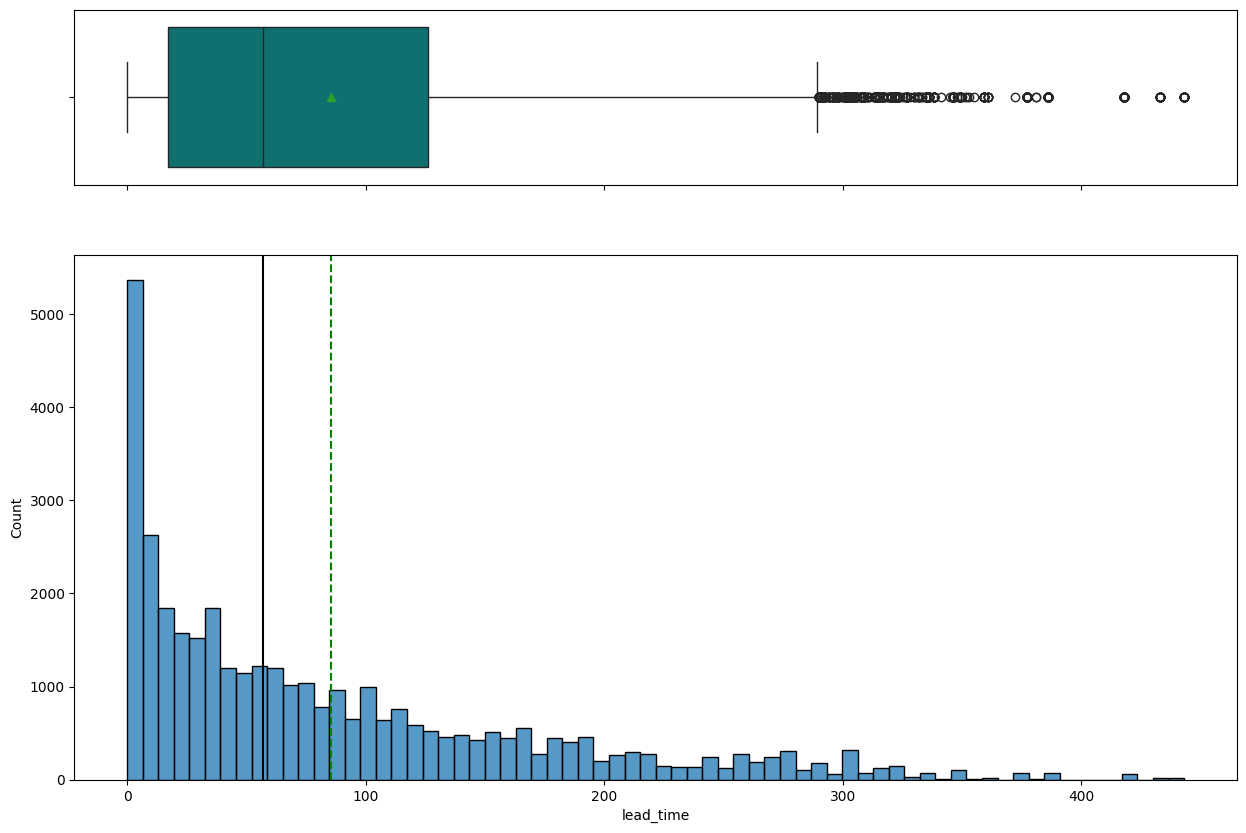

In [ ]:
histogram_boxplot(clean_data, "lead_time")

- **Last-Minute Bookings Dominance:** The histogram is extremely right-skewed, with the tallest bar sitting right at 0. This clearly indicates that a massive portion of the guests make last-minute bookings just a few days before their arrival.

- **Standard Planning Window:** The median lead time (represented by the black vertical line) is around 50 to 60 days. This tells us that exactly half of the guests book their rooms roughly 1.5 to 2 months in advance.

- **Extreme Outliers:** The boxplot at the top highlights a long tail of statistical outliers starting from roughly 290 days and stretching past 440 days. These represent a very rare group of highly organized guests who book their stays more than a year in advance!

#### Observation on arrival_month :-

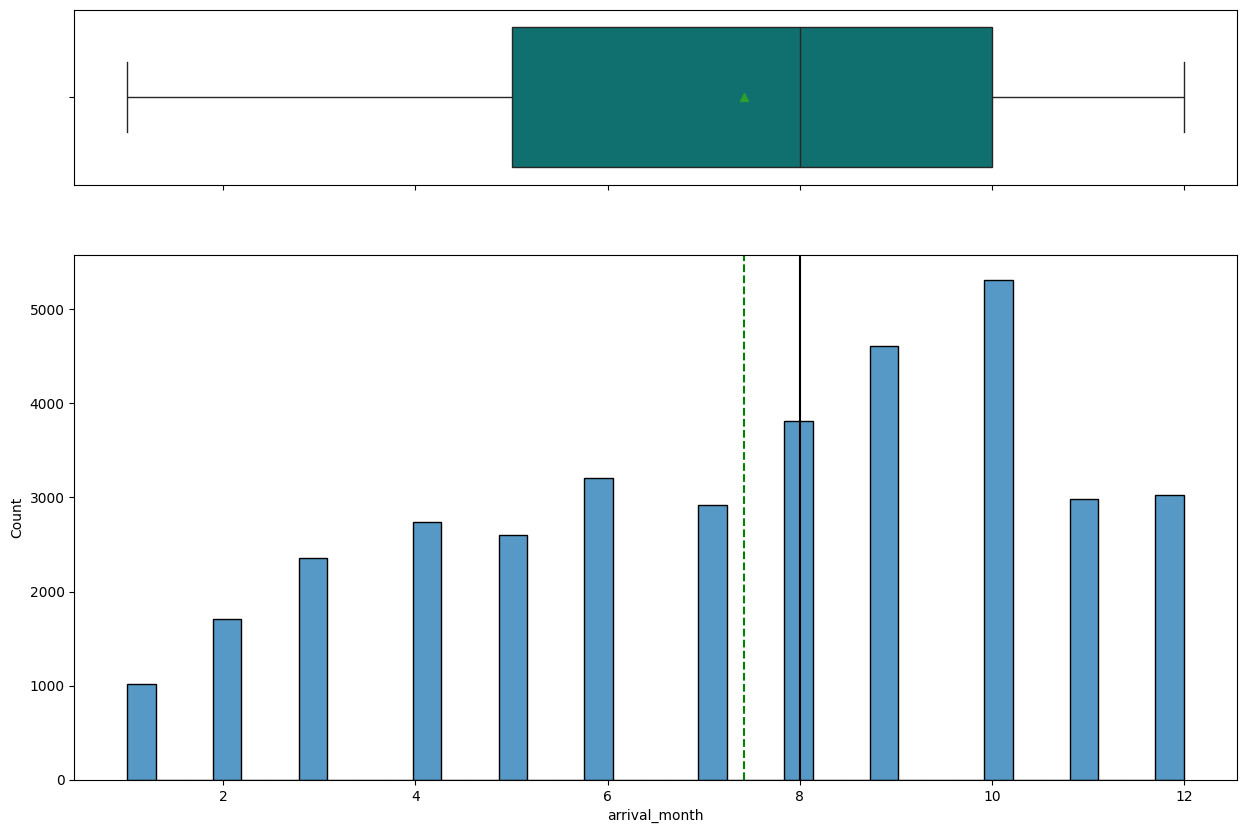

In [ ]:
histogram_boxplot(clean_data, "arrival_month")

- **Peak Season Confirmation:** The histogram peaks clearly at Month 10 (October), reaffirming it as the absolute busiest month for the hotel. The broader high-traffic season spans from Month 8 (August) to Month 10.

- **Slowest Period:** The lowest bar is at Month 1 (January), showing that the start of the year brings in the least amount of business.

- **Statistical Insight (Boxplot):** The median (black line) sits exactly at Month 8 (August). The wide box shows that the middle 50% of all hotel bookings happen between Month 5 (May) and Month 10 (October).

- **No Outliers:** As expected for a calendar variable, there are no outliers since the data is strictly contained between months 1 and 12.

#### Observation on arrival_date :-

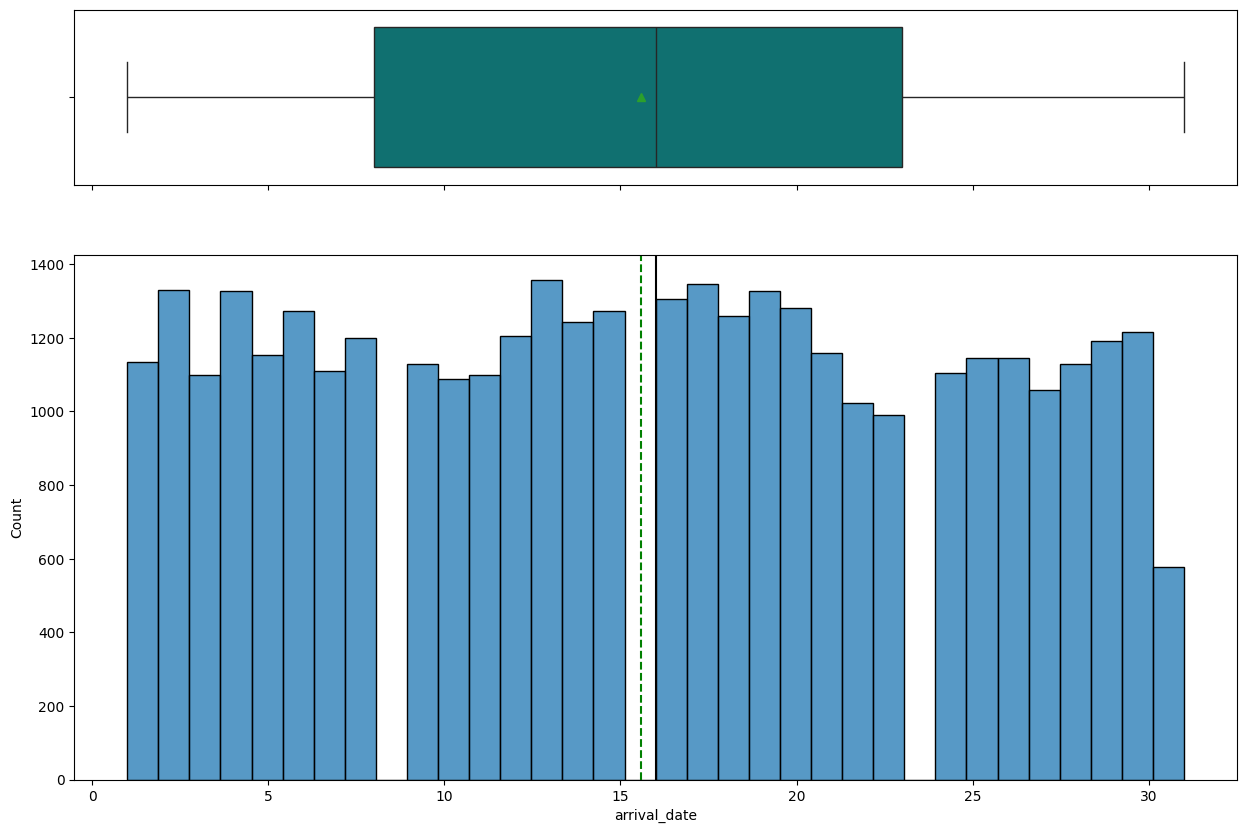

In [ ]:
histogram_boxplot(clean_data, "arrival_date")

- **Uniform Distribution:** Unlike other features, the arrival dates are spread very evenly across the entire month. There is no massive spike on any specific date, meaning guests check into the hotel consistently from the 1st to the 30th.

- **Month-End Drop:** There is a noticeable drop at the very end of the graph (the 31st). This is simply a natural calendar artifact, as 5 months out of the year do not have 31 days.

- **Statistical Insight (Boxplot):** The median (black vertical line) sits exactly in the middle of the month (around the 16th). Because the data is so perfectly spread out, the box is perfectly symmetrical and there are zero outliers.

#### Observation on market_segment_type :-

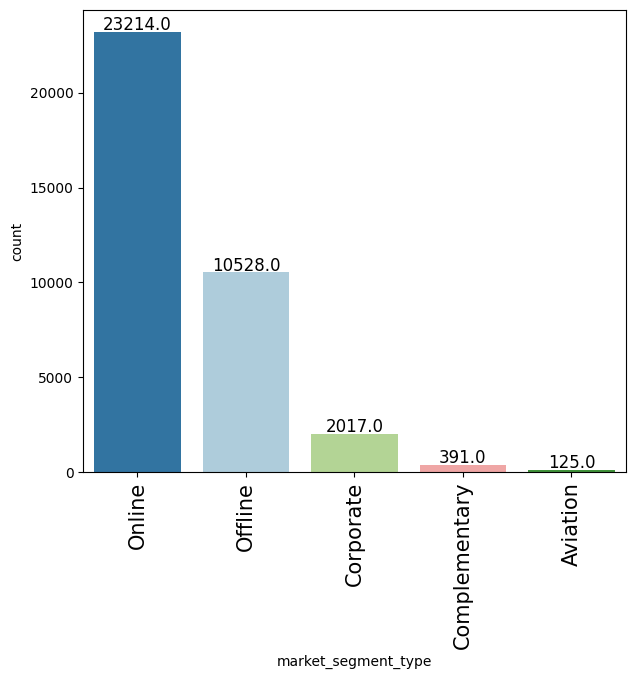

In [ ]:
labeled_barplot(clean_data, "market_segment_type")

- **Digital Dominance:** The 'Online' segment is the undisputed leader, bringing in the massive majority of the business with over 23,000 bookings. This proves that the hotel relies heavily on digital platforms (like MakeMyTrip, Agoda, or their own website) for its primary revenue.

- **Traditional Bookings:** The 'Offline' segment is the second most common (around 10,500 bookings), representing less than half of the online volume. These are likely direct phone calls or walk-in customers.

- **Minority Segments:** The remaining categories (Corporate, Complementary, and Aviation) make up a very tiny fraction of the overall data.

#### Observation on repeated_guest :-

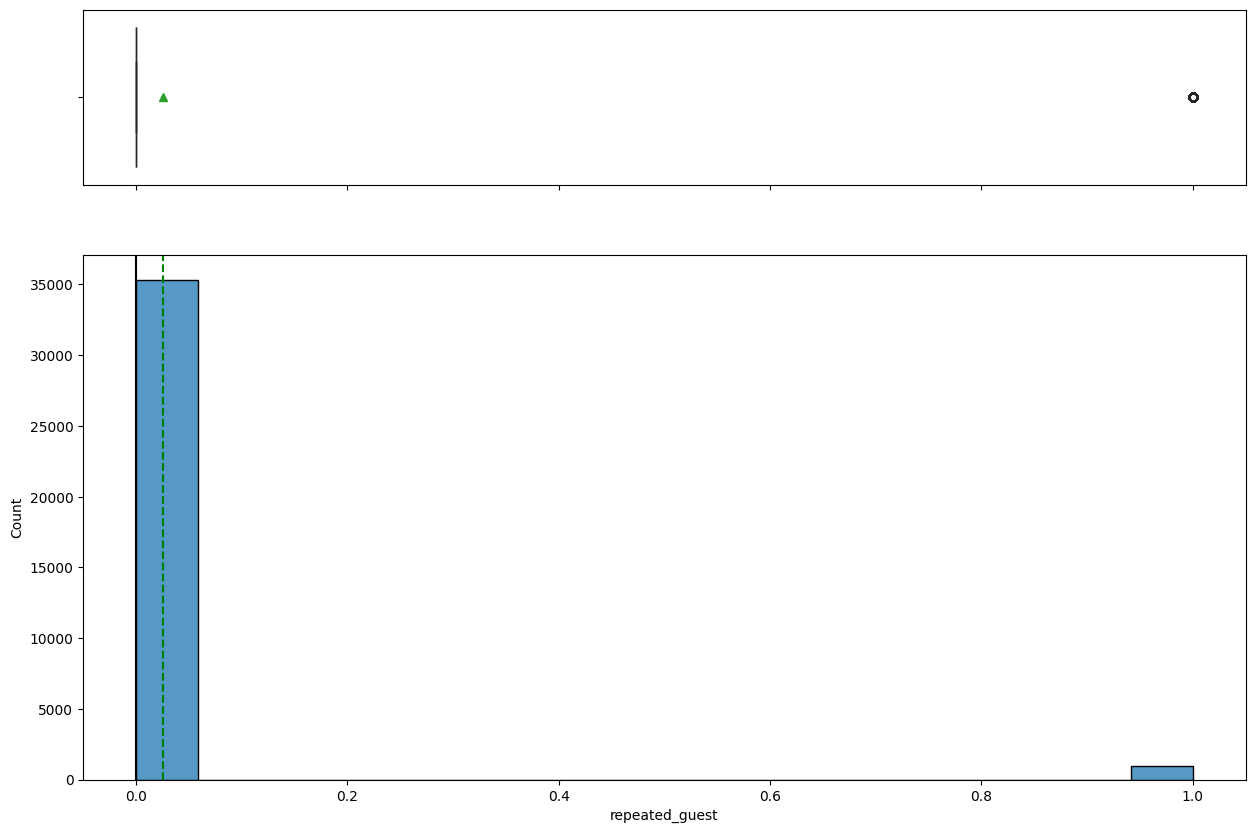

In [ ]:
histogram_boxplot(clean_data, "repeated_guest")

- **New Customer Dominance:** The overwhelming majority of the bookings (over 35,000) have a value of 0, meaning they are first-time visitors. This shows that the hotel's customer base is almost entirely made up of new guests.

- **Extremely Low Retention:** Only a very tiny fraction of the guests (value 1) are returning or repeated customers.

- **Statistical Insight (Boxplot):** Because almost the entire dataset is concentrated at 0, the boxplot collapses into a single vertical line. Mathematically, the few repeating guests are treated as statistical outliers by the boxplot.

#### Observation on no_of_previous_cancellations :-

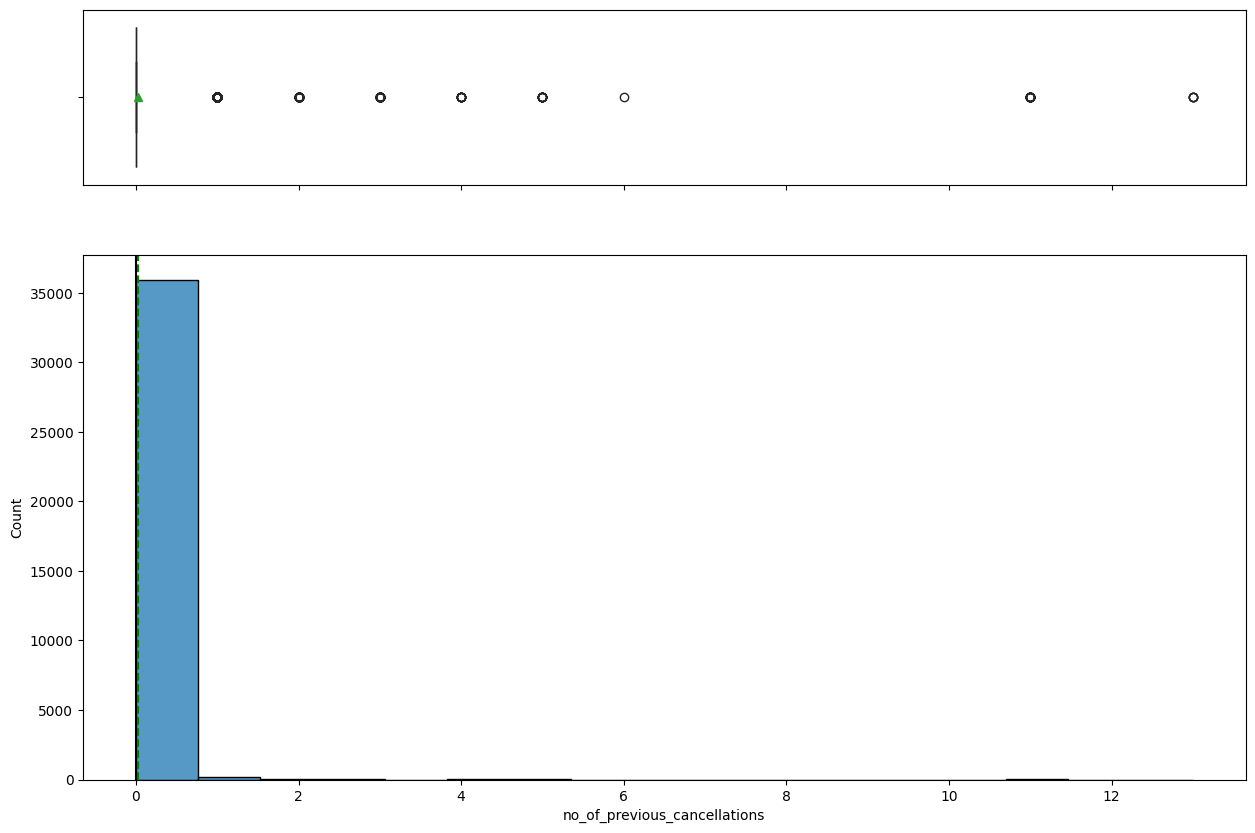

In [ ]:
histogram_boxplot(clean_data, "no_of_previous_cancellations")

- **Zero Cancellations Dominance:** The absolute majority of guests (over 35,000) have 0 previous cancellations. This perfectly aligns with our earlier finding that the hotel's customer base consists almost entirely of first-time visitors.

- **Extremely Rare History:** Guests who have a history of canceling previous bookings are exceptionally rare. The histogram bars for any value above 0 are practically invisible.

- **Statistical Outliers:** Because the data is so heavily concentrated precisely at 0, the boxplot collapses completely into a single line. The few individuals who do have a history of canceling (ranging from 1 up to 13 times) are marked as extreme statistical outliers by the hollow circles.

#### Observation on no_of_previous_bookings_not_canceled :-

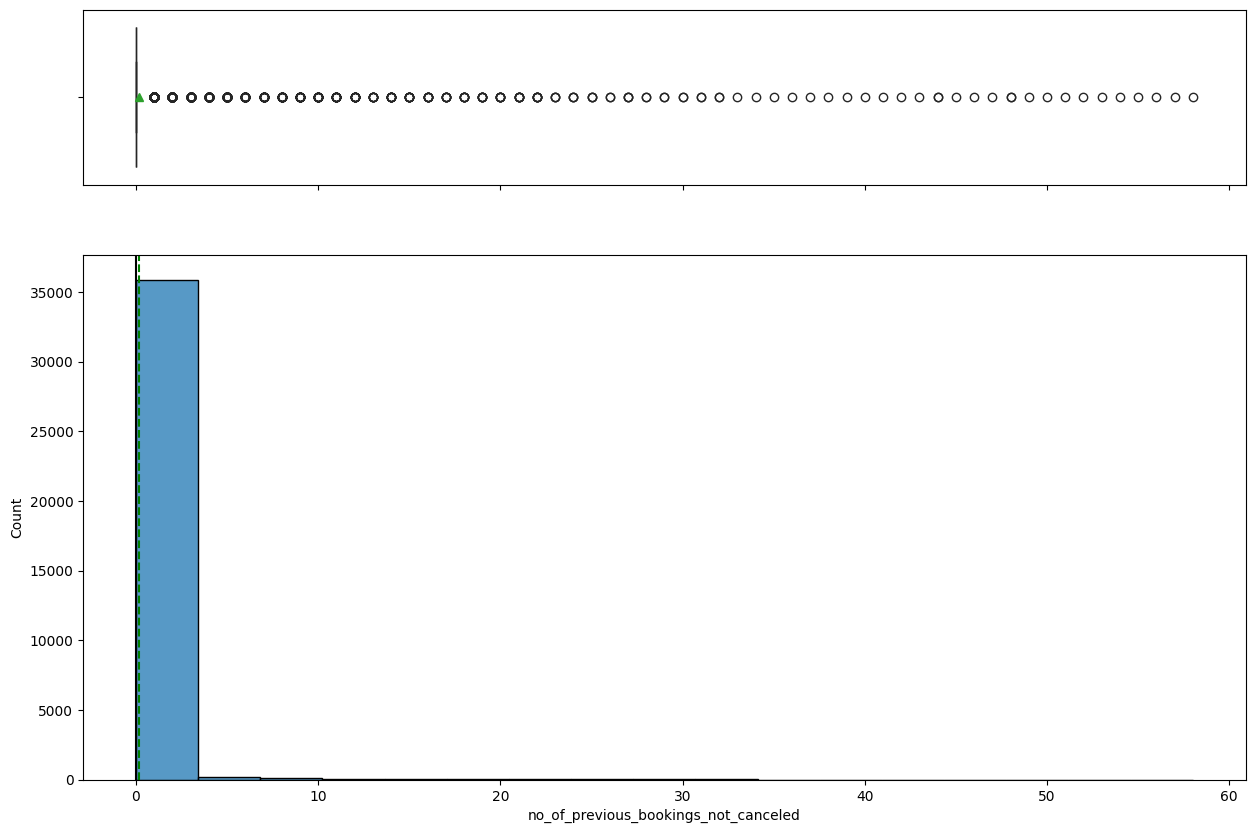

In [ ]:
histogram_boxplot(clean_data, "no_of_previous_bookings_not_canceled")

- **First-Time Visitors Dominance:** The vast majority of guests (over 35,000) have exactly 0 previous successful bookings. This perfectly aligns with our earlier findings that the hotel relies almost entirely on new, first-time customers.

- **Rare but Highly Loyal Guests (Outliers):** While repeating guests are very rare, the boxplot reveals a fascinating long tail of extreme outliers. There is a small group of highly loyal customers who have successfully stayed at the hotel anywhere from 10 to nearly 60 times in the past!

- **Statistical Insight:** Because the data is so heavily concentrated at 0, the boxplot collapses into a single vertical line. Mathematically, it treats any guest who has stayed even once before as a statistical outlier.

#### Observation on avg_price_per_room :-

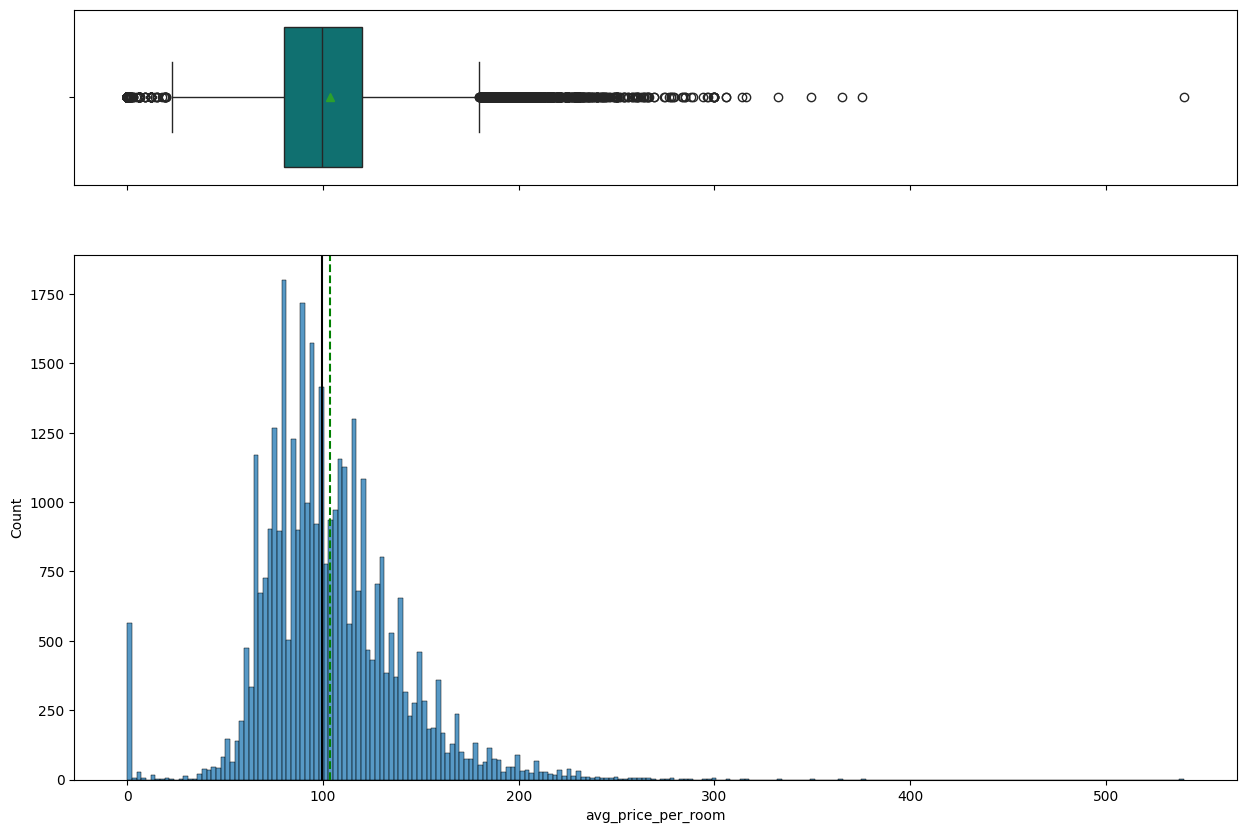

In [ ]:
histogram_boxplot(clean_data, "avg_price_per_room")

- **Standard Pricing:** The histogram shows a somewhat normal distribution, with the vast majority of room prices clustered around the 100 mark. The median and mean are very close to each other (around 100), indicating this is the typical baseline rate of the hotel.

- **Free Stays (The Zero Spike):** There is a very distinct and sharp spike exactly at 0. This perfectly aligns with our earlier findings about the 'Complementary' market segment, representing guests who are staying for free.

- **Premium Outliers:** The boxplot reveals a long right tail of statistical outliers stretching from 200 all the way past 500. These represent rare instances of highly expensive premium suites or peak dynamic pricing during high-demand periods.

#### Observation on no_of_special_requests :-

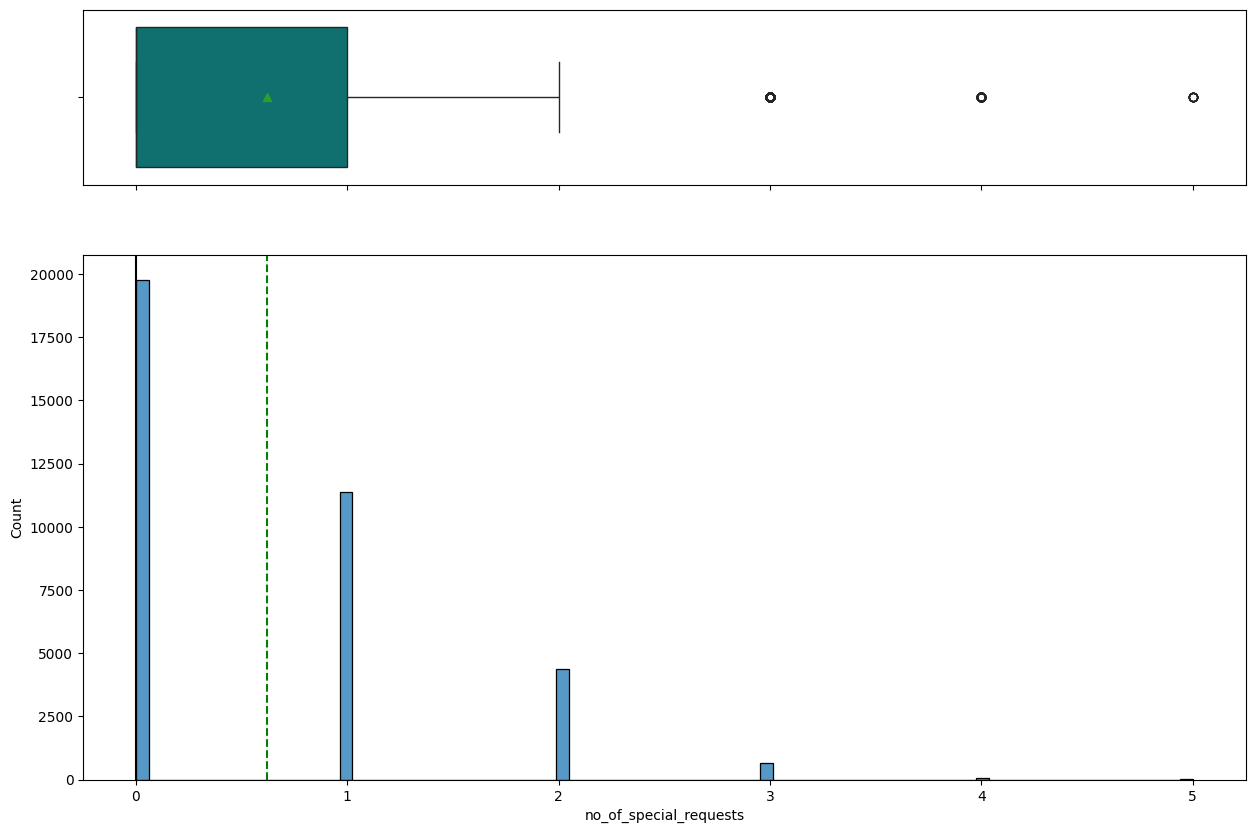

In [ ]:
histogram_boxplot(clean_data, "no_of_special_requests")

- **Standard Behavior (Zero Requests):** The majority of guests (nearly 20,000 bookings) make 0 special requests. A standard, straightforward booking without any extra demands is the most common behavior.

- **Moderate Requests:** Making 1 or 2 special requests is also quite common, representing a healthy chunk of engaged customers.

- **Rare Demands (Outliers):** Guests asking for 3, 4, or 5 special things are very rare. The boxplot cleanly captures this by marking any booking with 3 or more requests as a statistical outlier.

#### Observation on booking_status :-

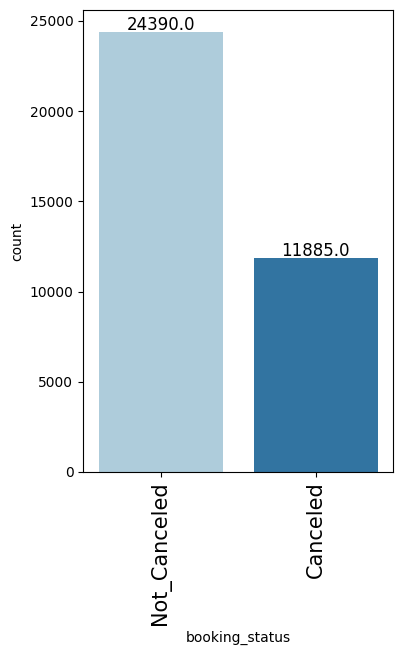

In [ ]:
labeled_barplot(clean_data, "booking_status")

- **Majority Outcome:** The majority of the bookings in the dataset (24,390) were successful and Not_Canceled.

- **High Cancellation Rate:** However, a very significant portion (11,885 bookings) were Canceled. This means roughly 33% (or 1 in every 3 bookings) ends up getting canceled.

- **Dataset Balance:** The target variable is somewhat imbalanced (roughly a 2:1 ratio), but there is still plenty of data for both categories to train a strong machine learning model.

### Bivariate analysis..

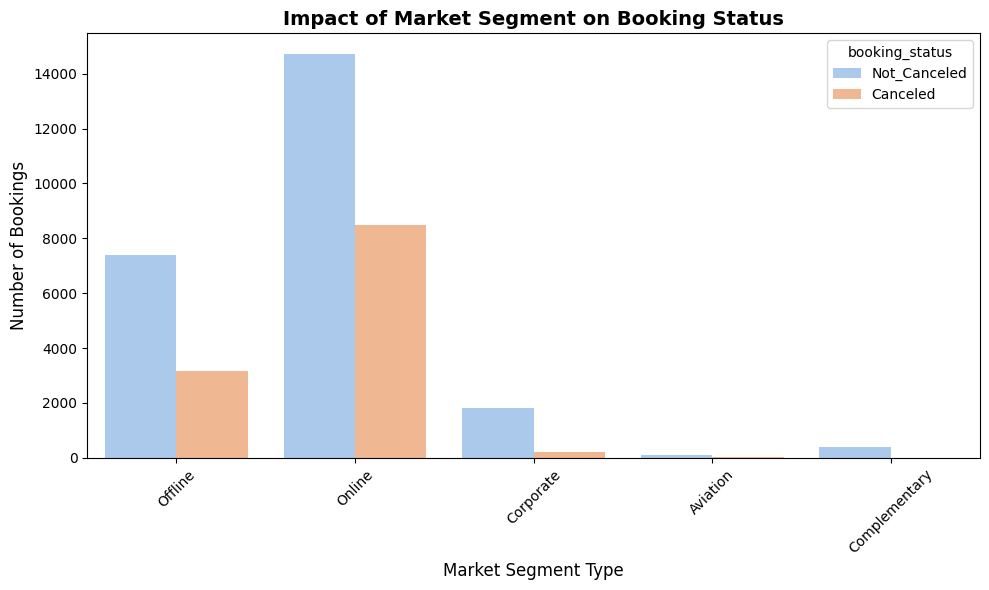

In [ ]:
# Categorical vs Target (Market Segment vs Booking Status)
plt.figure(figsize=(10,6))
sns.countplot(x = "market_segment_type", hue = "booking_status", data = clean_data, palette = "pastel")
plt.title("Impact of Market Segment on Booking Status", fontsize = 14, fontweight = "bold")
plt.xlabel("Market Segment Type", fontsize = 12)
plt.ylabel("Number of Bookings", fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

- **Online Segment (High Volume, High Risk):** The Online segment drives the most bookings, but it also has the highest absolute number of cancellations. A very significant proportion of online bookings end up getting canceled.

- **Offline Segment (More Reliable):** The Offline segment brings in the second-highest number of bookings, but its cancellation rate is noticeably lower compared to the Online segment. Offline customers are more likely to stick to their plans.

- **Corporate Reliability:** The Corporate segment shows extremely high reliability. Although the total volume is lower, the proportion of cancellations is remarkably small, making it a very secure revenue stream for the hotel.

- **Minor Segments:** 'Complementary' and 'Aviation' segments have very low booking volumes and almost zero cancellations.

/tmp/ipykernel_1903/2732138540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="booking_status", y = "lead_time", data = clean_data, palette = "Set2")


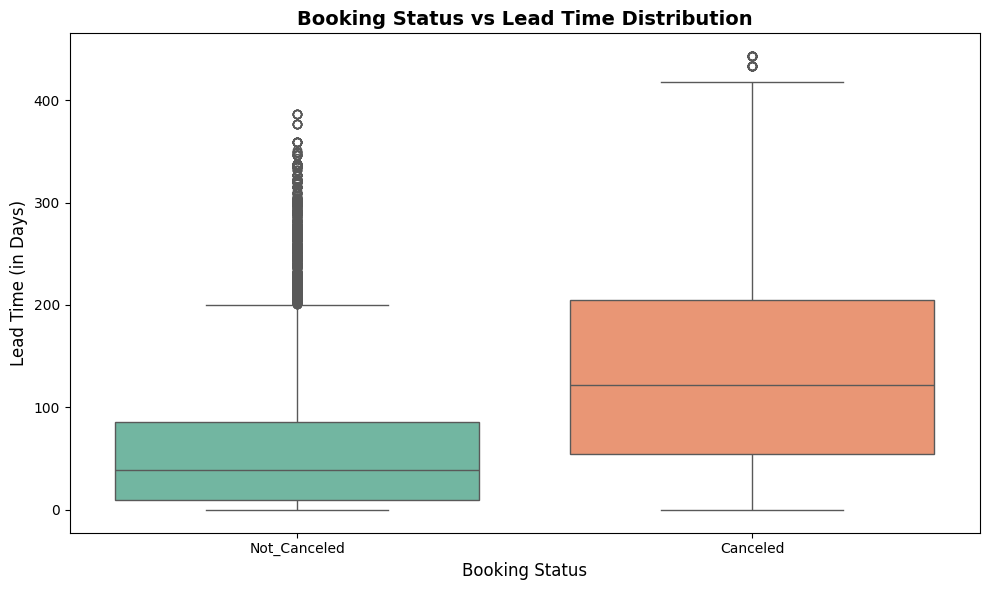

In [ ]:
# Numerical vs Target (Booking Status vs Lead Time)
plt.figure(figsize = (10,6))
sns.boxplot(x="booking_status", y = "lead_time", data = clean_data, palette = "Set2")
plt.title("Booking Status vs Lead Time Distribution", fontsize = 14, fontweight = "bold")
plt.xlabel("Booking Status", fontsize = 12)
plt.ylabel("Lead Time (in Days)", fontsize = 12)
plt.tight_layout()
plt.show()

- **Clear Upward Trend:** There is a very strong and clear relationship here: higher lead time leads to a higher chance of cancellation.

- **Not Canceled (Green Box):** Bookings that are not canceled generally have a much shorter lead time. The median (middle line) is very low, around 40 days. This means guests who book closer to their actual travel date are much more likely to show up.

- **Canceled (Orange Box):** Bookings that get canceled have a significantly higher median lead time (around 120 days) and a much wider box. This shows that when guests book their rooms 3 to 4 months in advance, there is a much higher risk that their plans will change, leading to a cancellation.

### Multivariate analysis..

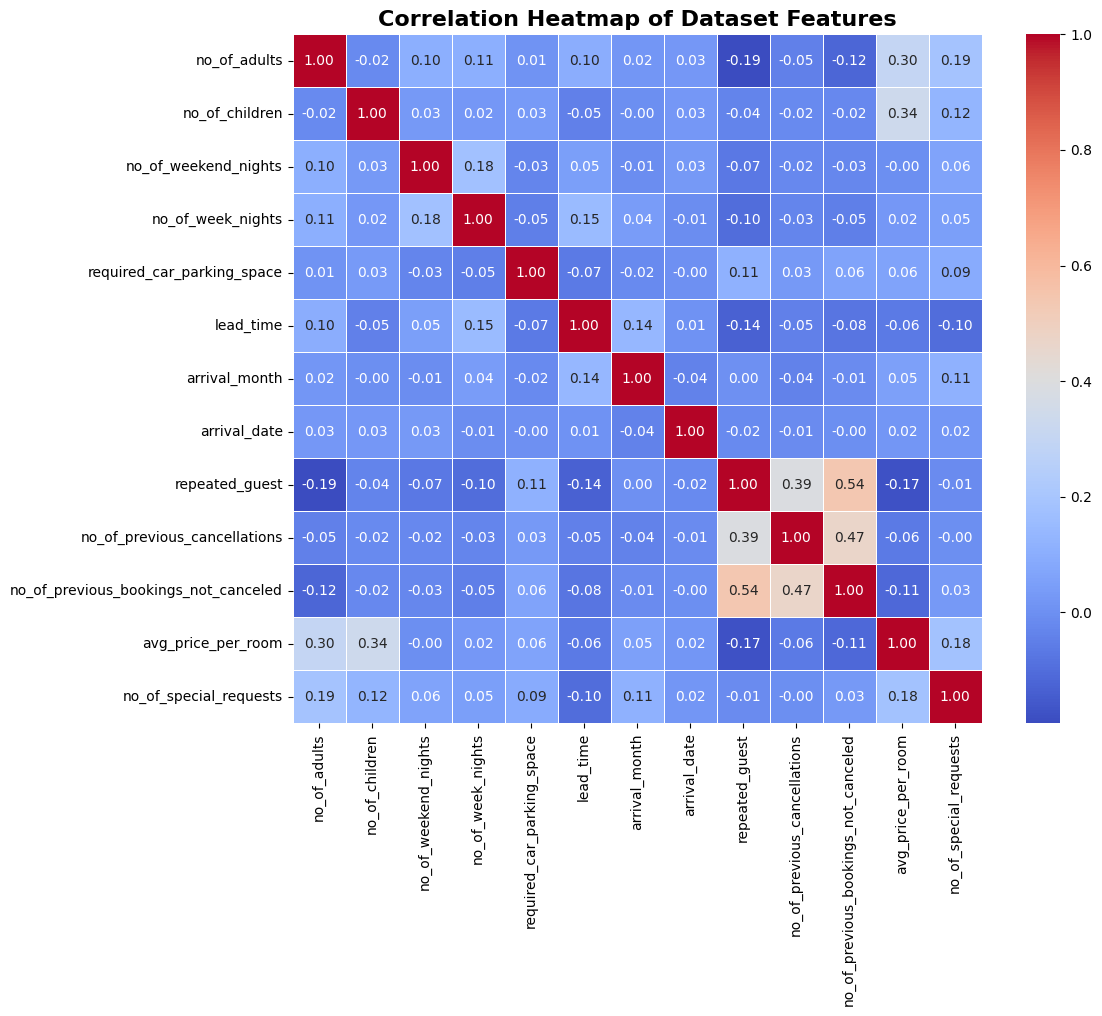

In [ ]:
numerical_cols = clean_data.select_dtypes(include=["int64","float64"])

corr_matrix = numerical_cols.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", linewidths = 0.5, square = True)

plt.title("Correlation Heatmap of Dataset Features", fontsize = 16, fontweight = "bold")
plt.tight_layout()
plt.show()

- **No Severe Multicollinearity:** The most important takeaway is that there are no highly correlated feature pairs (no values close to +0.90 or -0.90). Most of the grid is blue (close to 0), meaning almost every feature brings unique, independent information to the dataset. This is excellent for training a Machine Learning model.

- **The "Customer Loyalty" Cluster:** There is a moderate positive correlation (0.54 and 0.47) between repeated_guest, no_of_previous_bookings_not_canceled, and no_of_previous_cancellations. This makes perfect logical sense, as only repeated guests will have a history of previous successful or canceled bookings.

- **Pricing Factors:** There is a logical positive correlation between avg_price_per_room and both no_of_adults (0.30) and no_of_children (0.34). As the number of occupants increases, the room price naturally goes up.

## Removed Outliers..

In [ ]:
def cap_outliers_iqr(dataframe, column_name):
  Q1 = dataframe[column_name].quantile(0.25)
  Q3 = dataframe[column_name].quantile(0.75)

  IQR = Q3 - Q1

  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR

  dataframe[column_name] = dataframe[column_name].clip(lower = lower_limit, upper = upper_limit)

  print(f"Successfully remove outliers from {column_name} column. ")
  print(f"- Lower limit set to: {lower_limit}")
  print(f"- Upper_limit set to: {upper_limit}")

#### Capped outliers from lead_time column :-

In [ ]:
cap_outliers_iqr(clean_data, "lead_time")

Successfully remove outliers from lead_time column. 
- Lower limit set to: -146.5
- Upper_limit set to: 289.5


- **Logical Upper Capping:** The IQR method successfully established a maximum threshold of 289.5 days. Any extreme outliers (such as bookings made 400+ days in advance) have now been safely capped at this limit. This ensures our machine learning model won't be heavily skewed by rare, extremely early bookings.

- **Mathematical Lower Bound:** The lower limit resulted in a negative value (-146.5). Since a "negative" advance booking is impossible in reality (the minimum possible lead time is 0 for same-day check-ins), this simply confirms that no data points on the lower end required capping.

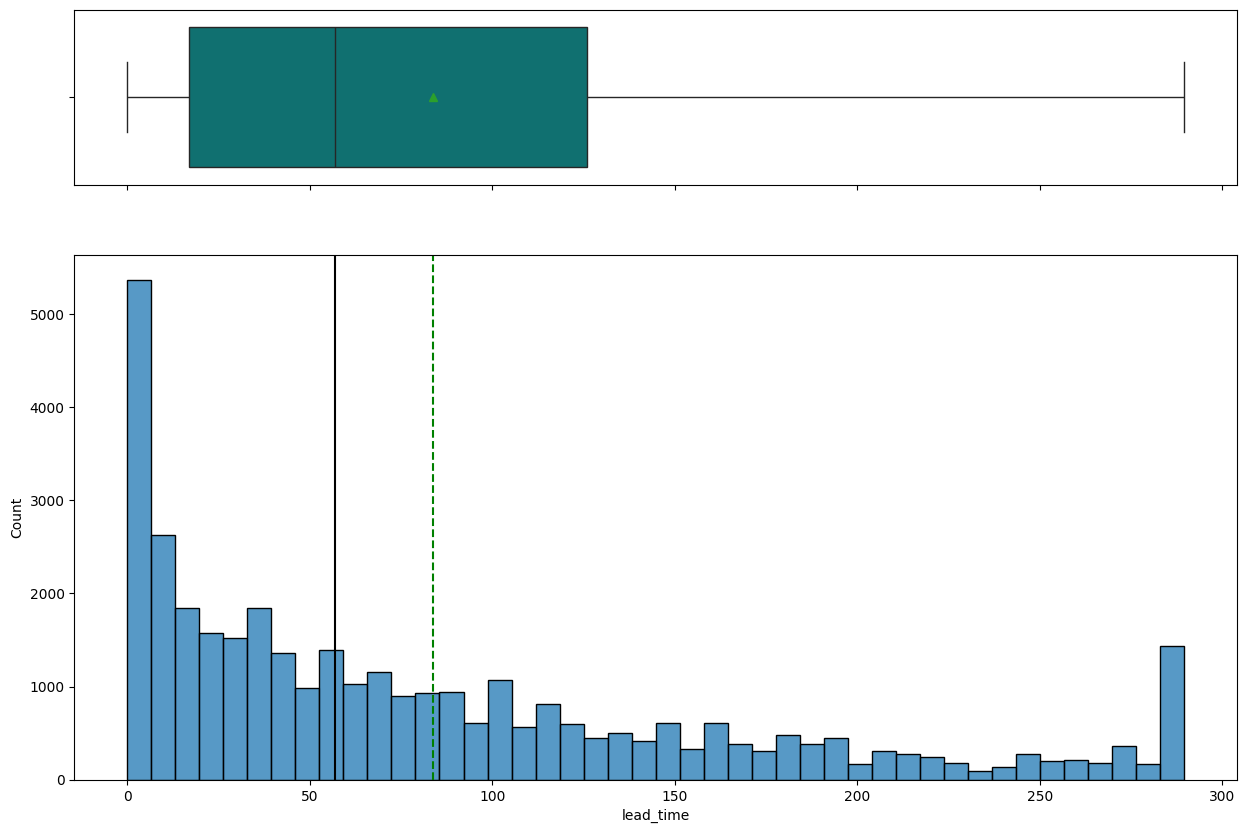

In [ ]:
# Checking our data
histogram_boxplot(clean_data, "lead_time")

#### Capped outliers from avg_price_per_room :-

In [ ]:
cap_outliers_iqr(clean_data, "avg_price_per_room")

Successfully remove outliers from avg_price_per_room column. 
- Lower limit set to: 20.749999999999993
- Upper_limit set to: 179.55


- **Premium Price Capping:** The upper limit is set at 179.55. Any highly expensive rooms or luxury suite prices (which previously went up to 500+) have been safely capped at this value. This prevents our machine learning model from getting confused by rare, extreme price points.

- **Handling Complementary Stays:** The lower limit is set at approximately 20.75. This is statistically significant because earlier, we saw a massive spike at '0' (representing complementary or free stays). The .clip() function has mathematically adjusted these '0' values up to the lower boundary (20.75). This normalizes the data distribution while still keeping those stays in the "lowest price" tier.

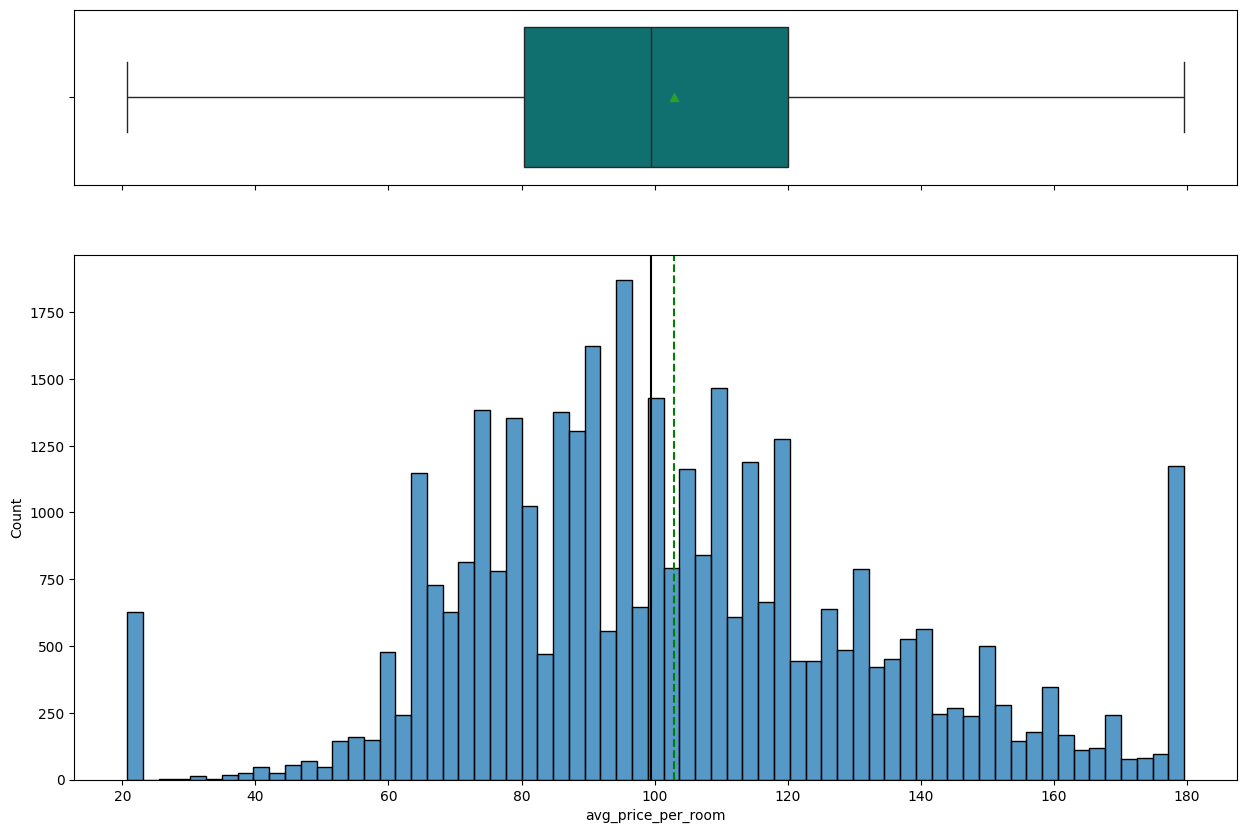

In [ ]:
histogram_boxplot(clean_data, "avg_price_per_room")

## Data Preprocessing..

#### Encoding :-

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = clean_data.select_dtypes(include=["object"]).columns
print("Encoding in progress for:", list(categorical_cols))
print("-"*50)

le = LabelEncoder()

for col in categorical_cols:
  clean_data[col] = le.fit_transform(clean_data[col])
  print(f"{col} successfully converted to numbers!")

print("-" * 50)
print("Data Encoding 100% Complete!")

Encoding in progress for: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']
--------------------------------------------------
type_of_meal_plan successfully converted to numbers!
room_type_reserved successfully converted to numbers!
market_segment_type successfully converted to numbers!
booking_status successfully converted to numbers!
--------------------------------------------------
Data Encoding 100% Complete!


- **Successful Transformation:** All string-based categorical features (type_of_meal_plan, room_type_reserved, market_segment_type) and the primary target variable (booking_status) have been successfully converted into integer formats (0, 1, 2, etc.) using Label Encoding.
- **Target Variable Assignment:** Based on alphabetical sorting, the LabelEncoder has internally assigned numerical weights to the target classes (e.g., 'Canceled' $\rightarrow$ 0, 'Not_Canceled' $\rightarrow$ 1).

In [ ]:
# Checking our data
clean_data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224.0,10,2,3,0,0,0,65.00,0,1
1,2,0,2,3,3,0,0,5.0,11,6,4,0,0,0,106.68,1,1
2,1,0,2,1,0,0,0,1.0,2,28,4,0,0,0,60.00,0,0
3,2,0,0,2,0,0,0,211.0,5,20,4,0,0,0,100.00,0,0
4,2,0,1,1,3,0,0,48.0,4,11,4,0,0,0,94.50,0,0


#### Splitting :-

In [ ]:
from sklearn.model_selection import train_test_split

X = clean_data.drop(columns = ["booking_status"])
y = clean_data["booking_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Data Successfully Split!")
print("-" * 40)
print(f"Total rows in original data: {clean_data.shape[0]}")
print(f"Rows for Traning (80%): {X_train.shape[0]}")
print(f"Rows for Testing (20%): {X_test.shape[0]}")

Data Successfully Split!
----------------------------------------
Total rows in original data: 36275
Rows for Traning (80%): 29020
Rows for Testing (20%): 7255


#### **Dataset Division:** The dataset of 36,275 records was successfully split into training and testing sets using the standard 80:20 ratio.

- **Training Set:** A substantial portion of the data, comprising 29,020 rows, has been allocated for the machine learning models to learn patterns and relationships.

- **Testing Set:** A separate, unseen set of 7,255 rows has been securely kept aside. This will act as the "final exam" to evaluate the true accuracy and generalizability of the trained models on new, real-world customer data.

#### Feature Scalling :-

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the Standard Scaler
scaler = StandardScaler()

# Fit and transform the traning data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data (No fitting here to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

print("Feature Scalling Complete!\n")
print("First row of scaled traning data:")
print(X_train_scaled[0])

Feature Scalling Complete!

First row of scaled traning data:
[ 0.30022247  2.20455934  1.37332412 -0.85691988 -0.49139485 -0.18165226
 -0.50672718 -0.7095969   0.84427754  0.16032895  0.65833163 -0.16265692
 -0.06351303 -0.08703155  1.82582455 -0.78836368]


- **StandardScaler:** This is the most standard method of statistical scaling. It sets the mean of the data to 0 and the standard deviation to 1.

- **fit_transform (for Train):** The model calculates the mean and variance of X_train (fit) and scales them (transform).

- **transform (for Test):** We don't re-fit here. The model applies the same old X_train calculations to X_test to avoid cheating!

# <a name='link2'>(i) Logistic Regression Model :-</a>

#### **Logistic Regression Model Initialization & Traning :-**

In [ ]:
# library import
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

# Logistic regression model initialization
log_reg = LogisticRegression(random_state = 42)

print("Training Logistic Regression Model...")
log_reg.fit(X_train_scaled, y_train)


Traning Logistic Regression Model...


LogisticRegression(random_state=42)

#### **Model Evalution :-**

In [ ]:
# Prediction of Testing data
y_pred_log = log_reg.predict(X_test_scaled)

In [ ]:
# Metrics Calculation
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log) # default focus on class "1"
recall_log = recall_score(y_test, y_pred_log)

print("\n" + "=" * 40)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy : {accuracy_log * 100:.2f}%")
print(f"Precision : {precision_log * 100:.2f}%")
print(f"Recall : {recall_log * 100:.2f}%")



LOGISTIC REGRESSION RESULTS
Accuracy : 80.32%
Precision : 82.38%
Recall : 89.67%


In [ ]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_log))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.62      0.68      2416
           1       0.82      0.90      0.86      4839

    accuracy                           0.80      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255



#### **Observation :-**

- **Overall Accuracy:** The baseline Logistic Regression model achieved a respectable overall accuracy of 80%. This indicates that the basic linear relationships in the dataset are strong enough to make correct predictions 8 out of 10 times.

- **Strong on Non-Cancellations (Class 1):** The model performs exceptionally well in predicting customers who will show up (Not_Canceled). It has a high Recall of 90% (0.90) for Class 1, meaning it correctly identifies almost all genuine guests.

- **Struggling with Cancellations (Class 0) - The Weak Point:** The major limitation of this linear model lies in predicting actual cancellations. The Recall for Class 0 is only 62% (0.62). This means out of all the customers who actually canceled, the model only caught 62% of them, completely missing the remaining 38%.

- **Linearity Conclusion:** This 38% "miss rate" proves that while some data relationships are linear, the actual behavior of customers canceling bookings is complex and non-linear. The Logistic Regression's straight-line mathematical boundary is failing to capture these complex hidden patterns.

# <a name='link2'>(ii) Decision Tree Model :-</a>

#### **Decision Tree Model Initialization & Traning :-**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Decision tree model initialization
dt_model = DecisionTreeClassifier(random_state = 42)

print("Training Decision Tree Model..")
dt_model.fit(X_train_scaled, y_train)

Traning Decision Tree Model..


DecisionTreeClassifier(random_state=42)

Model Evalution :-

In [ ]:
# Prediction of testing data
y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
# Metrics calculation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print("\n" + "="*40)
print("DECISION TREE RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_dt * 100:.2f}%")
print(f"Precision : {precision_dt * 100:.2f}%")
print(f"Recall    : {recall_dt * 100:.2f}%")
print("-" * 40)


DECISION TREE RESULTS
Accuracy  : 87.13%
Precision : 90.70%
Recall    : 89.92%
----------------------------------------


In [ ]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2416
           1       0.91      0.90      0.90      4839

    accuracy                           0.87      7255
   macro avg       0.85      0.86      0.86      7255
weighted avg       0.87      0.87      0.87      7255



#### **Observation :-**
- **Significant Accuracy Leap:** The Decision Tree model achieved an impressive overall accuracy of 87.13%, a substantial 7% improvement over the baseline Logistic Regression model (80%).

- **Massive Improvement in Cancellation Detection (Class 0 Recall):** The most critical metric for our business problem—the Recall for Class 0 (Canceled)—jumped dramatically from 62% to 82%. This means the model is now successfully identifying 20% more actual cancellations that the previous linear model completely missed.

- **Proof of Complex Non-Linearity:** This sharp performance increase mathematically proves that the hotel booking data contains complex, non-linear patterns (the "jalebi" effect). The Decision Tree's non-linear, condition-based architecture (IF-ELSE rules) successfully untangled these relationships where straight-line equations failed.

- **Balanced F1-Score:** The F1-score for Class 0 has also improved significantly to 0.81, indicating a very healthy balance between Precision (not falsely accusing guests of canceling) and Recall (catching the actual cancelers).

# <a name='link2'>(iii) K-Nearest Neighbors (KNN) Model :-</a>

#### **KNN Model Initialization & Traning :-**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# KNN Model initialization
knn_model = KNeighborsClassifier(n_neighbors = 5)

print("Training K-Nearest Neighbours (KNN) Model...")
knn_model.fit(X_train_scaled, y_train)

Training K-Nearest Neighbours (KNN) Model...


KNeighborsClassifier()

Model Evalution :-

In [ ]:
# Predicition of testing data
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
# Metrics calculation
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)

print("\n" + "="*40)
print("K-NEAREST NEIGHBOURS (KNN) RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_knn * 100:.2f}%")
print(f"Precision : {precision_knn * 100:.2f}%")
print(f"Recall    : {recall_knn * 100:.2f}%")
print("-" * 40)


K-NEAREST NEIGHBOURS (KNN) RESULTS
Accuracy  : 85.07%
Precision : 87.51%
Recall    : 90.54%
----------------------------------------


In [ ]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_knn))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2416
           1       0.88      0.91      0.89      4839

    accuracy                           0.85      7255
   macro avg       0.84      0.82      0.83      7255
weighted avg       0.85      0.85      0.85      7255



#### **Observation :-**
- **Intermediate Accuracy:** The KNN model achieved an overall accuracy of 85.07%. This places its performance right in the middle—significantly better than the baseline Logistic Regression (80%) but slightly behind the Decision Tree (87.13%).

- **Cancellation Recall (Class 0):** For our primary business focus (predicting actual cancellations), KNN achieved a Recall of 74%. While it successfully identifies a large portion of local neighborhood patterns, it still misses 26% of actual cancellations, making it less robust than the Decision Tree's 82% recall.

- **Algorithmic Insight:** The results indicate that while customers with similar feature profiles (neighbors) do share similar cancellation behaviors (proving the validity of distance-based metrics on this scaled data), the strict 'If-Else' non-linear boundaries of a Decision Tree are ultimately more effective for this specific tabular dataset.

# <a name='link2'>(iv) Naive Bayes Model :-</a>

#### **Naive Bayes Model Initialization & Traning :-**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Naive Bayes Model initialization
nb_model = GaussianNB()

print("Training Naive Bayes Model (Calculating Probabilities)...")
nb_model.fit(X_train_scaled, y_train)

Training Naive Bayes Model (Calculating Probabilities)...


GaussianNB()

Model Evalution :-

In [ ]:
# Predicition of testing data
y_pred_nb = nb_model.predict(X_test_scaled)

In [ ]:
# Metrics calculation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)

print("\n" + "="*40)
print("NAIVE BAYES RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_nb * 100:.2f}%")
print(f"Precision : {precision_nb * 100:.2f}%")
print(f"Recall    : {recall_nb * 100:.2f}%")
print("-" * 40)


NAIVE BAYES RESULTS
Accuracy  : 40.15%
Precision : 92.77%
Recall    : 11.14%
----------------------------------------


In [ ]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_nb))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.98      0.52      2416
           1       0.93      0.11      0.20      4839

    accuracy                           0.40      7255
   macro avg       0.64      0.55      0.36      7255
weighted avg       0.74      0.40      0.31      7255



#### **Observation :-**
- **Catastrophic Accuracy Drop:** The Naive Bayes model suffered a massive performance collapse, yielding a severely low overall accuracy of 40.15%, making it the worst-performing model in our pipeline.

- **The "Over-Prediction" Trap:** The model achieved an artificially high Recall of 98% for Class 0 (Cancellations), but with a dismal Precision of 36%. Simultaneously, its Recall for Class 1 dropped to just 11%. This indicates extreme model bias: it essentially panicked and predicted almost every customer as "Canceled," completely failing to identify genuine guests who would actually arrive.

- **Failure of the Independence Assumption:** This poor performance mathematically proves that the core "Naive" assumption of the algorithm—that all features are completely independent of one another—is entirely false for this hotel dataset. In reality, variables like lead_time, avg_price_per_room, and room_type are deeply interconnected, and ignoring these relationships destroyed the model's predictive capability.

# <a name='link2'>(v) Support Vector Machine (SVM) Model :-</a>

#### **SVM Model Initialization & Traning :-**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# SVM model initialization
svm_model = SVC(random_state = 42)

print("Training Support Vector Machine (SVM) Model...")
svm_model.fit(X_train_scaled, y_train)

Training Support Vector Machine (SVM) Model...


SVC(random_state=42)

Model Evalution :-

In [ ]:
# Prediction of testing data
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
# Matrics calculation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)

print("="*40)
print("SUPPORT VECTOR MACHINE (SVM) RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_svm * 100:.2f}%")
print(f"Precision : {precision_svm * 100:.2f}%")
print(f"Recall    : {recall_svm * 100:.2f}%")
print("-" * 40)

SUPPORT VECTOR MACHINE (SVM) RESULTS
Accuracy  : 83.83%
Precision : 84.56%
Recall    : 92.68%
----------------------------------------


In [ ]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2416
           1       0.85      0.93      0.88      4839

    accuracy                           0.84      7255
   macro avg       0.83      0.79      0.81      7255
weighted avg       0.84      0.84      0.83      7255



#### **Observation :-**
- **Moderate Overall Accuracy:** The SVM model achieved an accuracy of 83.83%. While mathematically robust, it failed to surpass the performance of the simpler Decision Tree (87.13%).

- **Suboptimal Cancellation Recall (Class 0):** For our primary business target, SVM only managed to identify 66% of actual cancellations. It heavily prioritized predicting the majority class (genuine guests, 93% recall) over untangling the complex patterns of cancellations.

- **Poor Cost-to-Benefit Ratio:** Given the significant computational time (high latency) required to train the SVM on nearly 29,000 rows, yielding only a 66% recall makes it highly inefficient for this specific tabular dataset compared to faster, rule-based algorithms.

# **Model Comparison Summary**

| Model | Overall Accuracy | Recall (Class 0 - Canceled) | Performance Remark |
| :--- | :--- | :--- | :--- |
| **Decision Tree** | **87.13%** | **82.00%** | **Winner** - Best at catching actual cancellations. |
| **KNN** | 85.07% | 74.00% | Average - Missed 26% of cancellations. |
| **SVM** | 83.83% | 66.00% | Slow - Failed to capture complex patterns effectively. |
| **Logistic Regression** | 80.00% | 62.00% | Too Basic - Linear mathematical boundaries failed here. |
| **Naive Bayes** | 40.15% | 98.00% *(Biased)* |  Failed - Over-predicted cancellations heavily due to false assumptions. |

---

### **Best Model for this Dataset: Decision Tree Classifier**

**Rationale (Why?):**

1. **Maximum Business Value (82% Recall):** The biggest financial loss for a hotel occurs when a guest cancels and the room remains vacant. The Decision Tree successfully identified the highest percentage (82%) of actual cancellations, minimizing potential revenue loss.
2. **Handling Complex Patterns (Non-Linear Data):** The dataset contains complex, non-linear relationships between customer features. Linear mathematical models (like Logistic Regression and SVM) attempt to draw straight decision boundaries and failed. The Decision Tree uses conditional **"IF-ELSE" rules**, allowing it to easily untangle and capture these hidden cancellation patterns.
3. **No Independence Assumption:** The Naive Bayes algorithm failed completely because it falsely assumed all columns were independent of each other. The Decision Tree, however, effectively evaluates combinations of features (e.g., how a long `lead_time` combined with a high `avg_price_per_room` influences a cancellation).

**Conclusion:** For tabular hotel data driven by complex customer behaviors and conditions, the Decision Tree algorithm creates the most accurate and practical decision boundaries.

## Q. Why did we selectively apply outlier capping only to lead_time and avg_price_per_room instead of all numerical columns?"

- **Continuous vs. Discrete Variables:** We selectively applied outlier capping (IQR method) only to lead_time and avg_price_per_room because they are continuous numerical variables with a wide, theoretically infinite variance. Extreme mathematical spikes in these columns act as "noise" and can severely skew distance-based algorithms and linear equations.

- **Preserving Valuable Behavioral Signals:** The other numerical columns (such as no_of_special_requests, no_of_previous_cancellations, no_of_adults, or repeated_guest) are discrete counts. Statistical outliers in these columns (e.g., a guest making 5 special requests or having 13 previous cancellations) are not data errors; they are rare but highly valuable behavioral signals.

- **Avoiding Information Loss:** Capping these discrete behavioral columns would result in a critical loss of information. It would force the model to treat a highly demanding guest the same as an average guest, destroying the exact patterns we want our machine learning model to learn.